# Electric-bus depot V1G/V2G use-case analysis — Thailand

This reproducible final-study notebook evaluates the Borommaratchachonnani Bus Depot at 15-minute resolution through 2024. It uses three individually modelled buses with hard route-energy, availability, charger-power, SOC, and terminal-SOC constraints.

The study reports operating outcomes only. It excludes non-traction depot demand, CAPEX, battery degradation, maintenance, and unmodelled social benefits.

| Family | Scenarios assessed | Main question |
| --- | --- | --- |
| References | D0 diesel; I01 managed unidirectional charging | What changes when diesel traction is electrified? |
| Economic V2G | Current and higher feed-in tariffs; completed tariff sensitivities | At what tariff does export become economically attractive? |
| Regional high-load import reduction | No export; current 5 kW limit; 450 kW technical sensitivity | How much can the depot reduce grid draw in high-load periods? |
| Renewable-responsive operation | No export; current 5 kW limit; 450 kW technical sensitivity | How can charging and export respond to renewable availability? |
| Rooftop PV operation | PV reference; current policy; higher tariff; high-load demand management | What PV value is available now, and what additional flexibility is available? |
| Emergency transfer sensitivity | 4-hour / 8-hour events; prepared / inherited SOC | What islanded fleet-transfer capability exists during a synthetic outage? |

## Detailed scenario and sensitivity register

| Family | ID / grouping | Scenario or sensitivity | What changes | Primary metric |
| --- | --- | --- | --- | --- |
| Reference | D0 | Diesel traction benchmark | Diesel fuel replaces traction electricity | Fuel cost and direct bus emissions |
| Reference | I01 | Managed unidirectional charging | Electric buses charge only; no scheduled export | Operating cost, import peak, mobility compliance |
| Economic V2G | I02a | Current feed-in tariff | 2.20 THB/kWh feed-in tariff; 5 kW export limit | Whether export occurs under current economics |
| Economic V2G | I02b | Illustrative higher tariff | 3.20 THB/kWh feed-in tariff; same 5 kW limit | Export onset and operating-cost effect |
| Economic V2G | I02-S | Supplementary tariff sweep | Additional completed feed-in tariff points | Export response to remuneration |
| Economic V2G | I02-T | Break-even checks | Targeted points around the efficiency-based break-even level | Refined export-onset threshold |
| High-load import reduction | I03 | No-export operation | Bus dispatch reduces depot import but cannot export | Import relief without grid export |
| High-load import reduction | I04a | Current regulatory limit | 5 kW export limit | Policy-constrained import relief |
| High-load import reduction | I04b | Technical sensitivity | 450 kW aggregate export capability | Technical upper-bound import relief |
| Renewable-responsive operation | I05 | No-export operation | Charging timing responds to the availability proxy; no export | Higher-availability charging |
| Renewable-responsive operation | I06a | Current regulatory limit | 5 kW export limit | Policy-constrained lower-availability export |
| Renewable-responsive operation | I06b | Technical sensitivity | 450 kW aggregate export capability | Technical upper-bound lower-availability export |
| Rooftop PV operation | PV reference | PV + unidirectional charging | Rooftop PV with no scheduled V2G service | PV self-consumption and curtailment |
| Rooftop PV operation | I07b | PV + current feed-in policy | Current 2.20 THB/kWh tariff and 5 kW export limit | Surplus-PV export and operator cost |
| Rooftop PV operation | I07c | PV + higher-tariff sensitivity | Higher feed-in tariff; same 5 kW export limit | Tariff effect on PV/export operation |
| Rooftop PV operation | I07d | PV + high-load demand management | Current tariff and limit; charging timing reduces high-load-period import without increasing the least-cost outcome | PV use and high-load grid exchange |
| Emergency transfer sensitivity | I08a-P | 4-hour outage; prepared SOC | All buses begin the event at 80% SOC | Prepared 4-hour transfer capability |
| Emergency transfer sensitivity | I08a-B | 4-hour outage; inherited SOC | SOC follows managed charging before the event | Normal-operation 4-hour readiness |
| Emergency transfer sensitivity | I08b-P | 8-hour outage; prepared SOC | All buses begin the event at 80% SOC | Prepared 8-hour transfer capability |
| Emergency transfer sensitivity | I08b-B | 8-hour outage; inherited SOC | SOC follows managed charging before the event | Normal-operation 8-hour readiness |

The tariff and technical cases are sensitivities, not present Thai market products or approvals. All cases retain the same traction-only boundary and hard mobility constraints.

The high-load signal is a regional demand proxy, not measured feeder congestion. Renewable metrics are availability proxies, not traced renewable electricity. I08 is a technical sensitivity and does not establish external-load supply or Thai regulatory approval.


## 1. Reproducible setup and common constraints


In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from flexi_mod.analysis.building_case_analysis import build_service_cost_gap, result_availability, stakeholder_matrix
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not find the FLEXIMOD project root')


PROJECT_ROOT = find_project_root()
INPUT_ROOT = PROJECT_ROOT / 'data' / 'input'
OUTPUT_ROOT = PROJECT_ROOT / 'data' / 'output' / 'building_use_case_analysis'
SOURCE_ROOT = PROJECT_ROOT / 'docs' / 'sources'
FORECAST_PATH = INPUT_ROOT / 'building_v1g_annual' / 'forecasts_df.csv'
ROOF_PATH = SOURCE_ROOT / 'borom_depot_roof_polygons.geojson'
ROUTE_PATH = SOURCE_ROOT / 'modeled_bus_route_corridors.geojson'

RUN_MISSING_CORE_CASES = False
RUN_SENSITIVITY_CASES = False

# D0 documented 2024 assumptions; see docs/sources/diesel_reference_2024.md.
DIESEL_FUEL_CONSUMPTION_L_PER_KM = 1.0 / 2.55  # BMTA diesel-bus average.
DIESEL_PRICE_THB_PER_L = 31.89  # 2024 national average retail diesel price.
DIESEL_TAILPIPE_CO2_KG_PER_L = 2.5503727392  # B7 fossil Scope 1, including CH4 and N2O.
DIESEL_BIOGENIC_CO2_KG_PER_L = 0.11507832  # B7 biogenic CO2, reported separately.
DIESEL_CARBON_TAX_THB_PER_L = 0.0  # No separate automobile carbon tax in 2024.
GRID_CO2_KG_PER_MWH = 499.9
CREDIT_GRID_EXPORT = False

CORE_CASES = {
    'V1G baseline': {'input': 'building_v1g_annual', 'study_case': 'building_v1g_annual', 'output': 'v1g_baseline'},
    'PV + unidirectional charging reference': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2b_pv_self_consumption', 'output': 'v2b_rooftop_pv'},
    'I02a least-cost V2G at current feed-in tariff': {'input': 'building_v2b_cost_annual', 'study_case': 'building_v2b_cost_annual', 'output': 'v2b_cost'},
    'I02b economically viable V2G export': {'input': 'building_v2g_tariff_sweep_annual', 'study_case': 'building_v2g_sweep_plus_1000', 'output': 'tariff_plus_1000'},
    'I03 maximum regional high-load import relief without export': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2b_grid_support_max_no_export', 'output': 'grid_support_no_export'},
    'I04a maximum regional high-load import relief at 5 kW policy limit': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_5kw', 'output': 'grid_support_export_5kw'},
    'I04b maximum regional high-load import relief at 450 kW technical sensitivity': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_450kw', 'output': 'grid_support_export_450kw'},
    'I05 maximum renewable-deficit support without export': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2b_renewable_shifting_max_no_export', 'output': 'renewable_shifting_no_export'},
    'I06a maximum renewable-deficit support at 5 kW policy limit': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_5kw', 'output': 'renewable_shifting_export_5kw'},
    'I06b maximum renewable-deficit support at 450 kW technical sensitivity': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_450kw', 'output': 'renewable_shifting_export_450kw'},
    'I07b rooftop PV operation at current export policy': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2b_pv_self_consumption', 'output': 'v2g_pv_current_policy'},
    'I07c rooftop PV operation at viable export tariff': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2g_pv_export_viable_tariff', 'output': 'v2g_pv_viable_tariff'},
    'I07d PV with high-load demand management': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2g_pv_cost_capped_high_load_relief', 'output': 'v2g_pv_cost_capped_high_load_relief'},
    'I08a-P emergency V2G 4 h prepared SOC': {'input': 'building_v2g_emergency_backup_4h_prepared', 'study_case': 'building_v2g_emergency_backup_4h_prepared', 'output': 'i08_4h_prepared'},
    'I08a-B emergency V2G 4 h inherited SOC': {'input': 'building_v2g_emergency_backup_4h_baseline', 'study_case': 'building_v2g_emergency_backup_4h_baseline', 'output': 'i08_4h_baseline'},
    'I08b-P emergency V2G 8 h prepared SOC': {'input': 'building_v2g_emergency_backup_8h_prepared', 'study_case': 'building_v2g_emergency_backup_8h_prepared', 'output': 'i08_8h_prepared'},
    'I08b-B emergency V2G 8 h inherited SOC': {'input': 'building_v2g_emergency_backup_8h_baseline', 'study_case': 'building_v2g_emergency_backup_8h_baseline', 'output': 'i08_8h_baseline'},
    'V2G current feed-in tariff': {'input': 'building_v2g_current_tariff_annual', 'study_case': 'building_v2g_current_tariff_annual', 'output': 'v2g_current_export'},
}
GRID_SUPPORT_CASES = {
    'No export': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2b_grid_support_max_no_export', 'output': 'grid_support_no_export', 'export_limit_kw': 0},
    '5 kW policy limit': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_5kw', 'output': 'grid_support_export_5kw', 'export_limit_kw': 5},
    '450 kW technical limit': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_450kw', 'output': 'grid_support_export_450kw', 'export_limit_kw': 450},
}
RENEWABLE_CASES = {
    'No export': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2b_renewable_shifting_max_no_export', 'output': 'renewable_shifting_no_export', 'export_limit_kw': 0},
    '5 kW policy limit': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_5kw', 'output': 'renewable_shifting_export_5kw', 'export_limit_kw': 5},
    '450 kW technical limit': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_450kw', 'output': 'renewable_shifting_export_450kw', 'export_limit_kw': 450},
}
TARIFF_CASES = {f'Export +{increment / 1000:.1f} THB/kWh': {'input': 'building_v2g_tariff_sweep_annual', 'study_case': ('building_v2g_sweep_current' if increment == 0 else f'building_v2g_sweep_plus_{increment}'), 'output': f'tariff_plus_{increment}', 'increment_thb_per_kwh': increment / 1000} for increment in range(0, 5001, 500)}

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'blue': '#0072B2', 'orange': '#D55E00', 'green': '#009E73', 'purple': '#7B61A8', 'grey': '#6B7280'}
print(f'Project root: {PROJECT_ROOT}')
print(f'Analysis outputs: {OUTPUT_ROOT}')


Project root: /root/FLEXIMOD
Analysis outputs: /root/FLEXIMOD/data/output/building_use_case_analysis


In [2]:
def output_dir(spec: dict) -> Path:
    return OUTPUT_ROOT / spec['output']


def run_case(label: str, spec: dict, allow_run: bool) -> None:
    destination = output_dir(spec)
    summary_path = destination / 'summary_indicators.csv'
    dispatch_path = destination / 'dispatch_results.csv'
    if summary_path.exists() and dispatch_path.exists():
        return
    if not allow_run:
        print(f'Missing {label}: {destination}')
        return
    destination.mkdir(parents=True, exist_ok=True)
    command = [sys.executable, '-m', 'flexi_mod.simulation.run_case', '--case', str(INPUT_ROOT / spec['input']), '--study-case', spec['study_case'], '--output-dir', str(destination), '--no-plots']
    print(f'Running {label}')
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)


for label, spec in CORE_CASES.items():
    run_case(label, spec, RUN_MISSING_CORE_CASES)

print('Core annual outputs available:', sum((output_dir(spec) / 'summary_indicators.csv').exists() for spec in CORE_CASES.values()), '/', len(CORE_CASES))


Core annual outputs available: 18 / 18


## 2. Diesel and managed-charging references


### Diesel benchmark assumptions

The diesel benchmark uses the same per-timestep route kilometres, with bus traction supplied by diesel. It is a traction-only benchmark: depot building electricity, demand charges, vehicle capital costs, maintenance, upstream fuel emissions, and battery manufacturing are excluded.

| D0 input | Value | Treatment |
| --- | ---: | --- |
| Diesel consumption | 1 / 2.55 = 0.3922 L/km | BMTA diesel-bus average |
| Diesel price | 31.89 THB/L | 2024 annual average retail price; no further fuel tax added |
| Bus emissions | 2.5504 kgCO2e/L | B7 fossil Scope 1, including CH4 and N2O |
| B7 biogenic CO2 | 0.1151 kgCO2/L | Reported separately; excluded from Scope 1 total |
| Carbon tax | 0 THB/L | No separate automobile carbon tax in 2024 |

Sources and scope are documented in `docs/sources/diesel_reference_2024.md`.


In [3]:
forecast = pd.read_csv(FORECAST_PATH, parse_dates=['datetime']).set_index('datetime')
distance_columns = [column for column in forecast if column.endswith('_trip_distance_km')]
if not distance_columns:
    raise ValueError('No per-bus trip-distance columns were found')
dt_hours = float(forecast.index.to_series().diff().dropna().dt.total_seconds().median() / 3600)
route_totals = forecast[distance_columns].sum().rename(lambda value: value.removesuffix('_trip_distance_km')).rename('annual_distance_km')
display(route_totals.to_frame())

total_distance_km = float(route_totals.sum())
diesel_litre = total_distance_km * DIESEL_FUEL_CONSUMPTION_L_PER_KM
diesel_fuel_cost = diesel_litre * (DIESEL_PRICE_THB_PER_L + DIESEL_CARBON_TAX_THB_PER_L)
diesel_bus_scope1_co2 = diesel_litre * DIESEL_TAILPIPE_CO2_KG_PER_L
diesel_biogenic_co2 = diesel_litre * DIESEL_BIOGENIC_CO2_KG_PER_L
diesel_total_cost = diesel_fuel_cost
diesel_operational_co2 = diesel_bus_scope1_co2

diesel_row = {
    'scenario': 'Diesel benchmark', 'distance_km': total_distance_km, 'fuel_litre': diesel_litre,
    'diesel_fuel_cost_THB': diesel_fuel_cost, 'diesel_carbon_tax_THB': diesel_litre * DIESEL_CARBON_TAX_THB_PER_L,
    'energy_cost_THB': diesel_fuel_cost, 'demand_charge_THB': 0.0, 'total_cost_THB': diesel_total_cost,
    'grid_import_MWh': 0.0, 'grid_export_MWh': 0.0,
    'peak_grid_import_MW': 0.0, 'operational_CO2_kg': float(diesel_operational_co2),
    'diesel_bus_scope1_CO2e_kg': float(diesel_bus_scope1_co2), 'diesel_biogenic_CO2_kg': float(diesel_biogenic_co2),
    'pv_available_MWh': 0.0, 'pv_used_MWh': 0.0, 'pv_curtailment_MWh': 0.0,
    'grid_import_during_stress_MWh': 0.0,
    'renewable_alignment_score': np.nan,
}
display(pd.Series(diesel_row).to_frame('value'))


,annual_distance_km
bus_route_7k,87840.0
bus_route_79,102480.0
bus_route_101,105408.0


,value
scenario,Diesel benchmark
distance_km,295728.0
fuel_litre,115971.764706
diesel_fuel_cost_THB,3698339.576471
diesel_carbon_tax_THB,0.0
energy_cost_THB,3698339.576471
demand_charge_THB,0.0
total_cost_THB,3698339.576471
grid_import_MWh,0.0
grid_export_MWh,0.0


## 3. Load annual outputs, availability, and common KPIs


In [4]:
def load_result(label: str, spec: dict) -> tuple[dict, pd.DataFrame] | None:
    summary_path = output_dir(spec) / 'summary_indicators.csv'
    dispatch_path = output_dir(spec) / 'dispatch_results.csv'
    if not summary_path.exists() or not dispatch_path.exists():
        return None
    summary = pd.read_csv(summary_path).iloc[0]
    dispatch = pd.read_csv(dispatch_path, parse_dates=['datetime']).set_index('datetime')
    # Apply one common 2024 renewable-availability signal to every case.
    # Most cases do not need the signal to optimise, but all cases need it for a fair comparison.
    signal_path = INPUT_ROOT / 'building_v2b_renewable_alignment_annual' / 'forecasts_df.csv'
    signal_frame = pd.read_csv(signal_path, usecols=['datetime', 'renewable_availability_weight', 'renewable_rich_threshold'], parse_dates=['datetime']).set_index('datetime')
    renewable_rich_threshold = float(signal_frame['renewable_rich_threshold'].iloc[0])
    signal = signal_frame['renewable_availability_weight']
    signal.index = signal.index.tz_localize(dispatch.index.tz)
    dispatch['renewable_availability_weight'] = signal.reindex(dispatch.index)
    if dispatch['renewable_availability_weight'].isna().any():
        raise ValueError(f'Renewable signal does not cover {label}')
    # This is an availability-weighted charging indicator, not a claim about metered renewable electrons.
    common_renewable_absorbed = float((dispatch['bus_charge_MWh'] * dispatch['renewable_availability_weight']).sum())
    renewable_rich_charge = float(dispatch.loc[dispatch['renewable_availability_weight'] >= renewable_rich_threshold, 'bus_charge_MWh'].sum())
    # Study boundary: traction charging and V2X only.  A legacy output may contain
    # a building-demand column, so remove it before calculating electric-case KPIs.
    legacy_building_demand = dispatch.get('building_demand_MWh', pd.Series(0.0, index=dispatch.index))
    dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
    dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
    dispatch['traction_net_grid_import_MWh'] = dispatch['traction_grid_import_MWh'] - dispatch['grid_export_MWh']
    imported_co2 = float(dispatch['traction_grid_import_MWh'].sum()) * GRID_CO2_KG_PER_MWH
    export_credit = float(dispatch['grid_export_MWh'].sum()) * GRID_CO2_KG_PER_MWH if CREDIT_GRID_EXPORT else 0.0
    row = {
        'scenario': label, 'distance_km': float(summary['total_bus_trip_distance_km']), 'fuel_litre': 0.0,
        'energy_cost_THB': float(summary['total_energy_cost']), 'demand_charge_THB': float(summary['total_demand_charge_cost']),
        'total_cost_THB': float(summary['total_cost']), 'grid_import_MWh': float(dispatch['traction_grid_import_MWh'].sum()),
        'grid_export_MWh': float(summary['total_grid_export_MWh']), 'peak_grid_import_MW': float(dispatch['traction_grid_import_MWh'].max() / 0.25),
        'peak_grid_export_MW': float(summary.get('peak_grid_export_MW', 0.0)),
        'unmet_trip_energy_MWh': float(summary.get('total_unmet_trip_energy_MWh', 0.0)),
        'operational_CO2_kg': imported_co2 - export_credit,
        'pv_available_MWh': float(summary.get('total_pv_available_generation_MWh', 0.0)),
        'pv_used_MWh': float(summary.get('total_pv_generation_MWh', 0.0)),
        'pv_curtailment_MWh': float(summary.get('total_pv_curtailment_MWh', 0.0)),
        'grid_import_during_stress_MWh': float(summary.get('grid_import_during_regional_stress_MWh', np.nan)),
        'renewable_alignment_score': float(summary.get('renewable_alignment_score', np.nan)),
        'renewable_absorbed_MWh': common_renewable_absorbed,
        'renewable_rich_charge_MWh': renewable_rich_charge,
        'renewable_signal_mean': float(dispatch['renewable_availability_weight'].mean()),
        'renewable_tagged_absorbed_MWh': float(summary.get('renewable_equivalent_absorbed_MWh', 0.0)),
        'renewable_delivered_MWh': float(summary.get('renewable_equivalent_delivered_MWh', 0.0)),
        'renewable_to_site_MWh': float(summary.get('renewable_equivalent_discharge_to_site_MWh', 0.0)),
        'renewable_export_MWh': float(summary.get('renewable_equivalent_grid_export_MWh', 0.0)),
        'renewable_conversion_loss_MWh': float(summary.get('renewable_equivalent_conversion_loss_MWh', 0.0)),
        'renewable_deficit_support_MWh': float(summary.get('renewable_deficit_weighted_discharge_MWh', 0.0)),
        'emergency_transfer_MWh': float(summary.get('emergency_v2g_transfer_MWh', 0.0)),
        'peak_emergency_transfer_MW': float(summary.get('peak_emergency_v2g_transfer_MW', 0.0)),
        'synthetic_outage_duration_hours': float(summary.get('synthetic_outage_duration_hours', 0.0)),
        'recovery_grid_import_MWh': float(summary.get('recovery_grid_import_MWh', 0.0)),
    }
    return row, dispatch


electric_rows = []
dispatch_by_case = {}
for label, spec in CORE_CASES.items():
    loaded = load_result(label, spec)
    if loaded is not None:
        row, dispatch = loaded
        electric_rows.append(row)
        dispatch_by_case[label] = dispatch

if 'V1G baseline' in dispatch_by_case:
    baseline_dispatch = dispatch_by_case['V1G baseline']
    for row in electric_rows:
        label = row['scenario']
        dispatch = dispatch_by_case[label]
        common_index = baseline_dispatch.index.intersection(dispatch.index)
        baseline_net = baseline_dispatch.loc[common_index, 'traction_net_grid_import_MWh']
        case_net = dispatch.loc[common_index, 'traction_net_grid_import_MWh']
        relief = baseline_net - case_net
        weight = dispatch.loc[common_index, 'grid_congestion_weight']
        threshold = float(dispatch.loc[common_index, 'grid_stress_threshold'].iloc[0])
        stressed = weight >= threshold
        row['grid_support_during_stress_MWh'] = float(relief.loc[stressed].sum())
        row['maximum_grid_support_MW'] = float(relief.max() / 0.25)
        row['rebound_import_MWh'] = float((-relief.loc[~stressed]).clip(lower=0).sum())

comparison = pd.DataFrame([diesel_row, *electric_rows]).set_index('scenario')
comparison['cost_THB_per_km'] = comparison['total_cost_THB'] / comparison['distance_km']
comparison['operational_CO2_kg_per_km'] = comparison['operational_CO2_kg'] / comparison['distance_km']
if 'V1G baseline' in comparison.index:
    reference = comparison.loc['V1G baseline']
    comparison['cost_saving_vs_V1G_pct'] = 100 * (reference['total_cost_THB'] - comparison['total_cost_THB']) / reference['total_cost_THB']
    comparison['peak_reduction_vs_V1G_pct'] = 100 * (reference['peak_grid_import_MW'] - comparison['peak_grid_import_MW']) / reference['peak_grid_import_MW']
else:
    comparison['cost_saving_vs_V1G_pct'] = np.nan
    comparison['peak_reduction_vs_V1G_pct'] = np.nan
columns = ['distance_km', 'total_cost_THB', 'cost_THB_per_km', 'cost_saving_vs_V1G_pct', 'grid_import_MWh', 'grid_export_MWh', 'peak_grid_import_MW', 'peak_grid_export_MW', 'grid_support_during_stress_MWh', 'maximum_grid_support_MW', 'rebound_import_MWh', 'renewable_absorbed_MWh', 'renewable_rich_charge_MWh', 'renewable_tagged_absorbed_MWh', 'renewable_delivered_MWh', 'renewable_to_site_MWh', 'renewable_export_MWh', 'renewable_conversion_loss_MWh', 'renewable_deficit_support_MWh', 'unmet_trip_energy_MWh', 'pv_used_MWh', 'pv_curtailment_MWh']
display(comparison[columns].round(3))


/tmp/ipykernel_2021259/1583869699.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
/tmp/ipykernel_2021259/1583869699.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
/tmp/ipykernel_2021259/1583869699.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

,distance_km,total_cost_THB,cost_THB_per_km,cost_saving_vs_V1G_pct,grid_import_MWh,grid_export_MWh,peak_grid_import_MW,peak_grid_export_MW,grid_support_during_stress_MWh,maximum_grid_support_MW,...,renewable_rich_charge_MWh,renewable_tagged_absorbed_MWh,renewable_delivered_MWh,renewable_to_site_MWh,renewable_export_MWh,renewable_conversion_loss_MWh,renewable_deficit_support_MWh,unmet_trip_energy_MWh,pv_used_MWh,pv_curtailment_MWh
scenario,,,,,,,,,,,,,,,,,,,,,
Diesel benchmark,295728.00,3698339.576,12.506,-159.082,0.000,0.000,0.000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000
V1G baseline,295728.00,1427478.195,4.827,0.000,389.116,0.000,0.087,0.000,0.000,0.000,...,36.535,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
PV + unidirectional charging reference,295728.00,499935.082,1.691,64.978,130.293,0.000,0.066,0.000,2.920,0.087,...,134.252,0.000,0.000,0.0,0.000,0.000,0.000,0.0,258.823,491.432
I02a least-cost V2G at current feed-in tariff,295728.00,1427477.456,4.827,0.000,389.116,0.000,0.087,0.000,-0.289,0.087,...,32.498,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I02b economically viable V2G export,295728.00,1427339.981,4.827,0.010,390.699,1.428,0.087,0.005,-0.044,0.092,...,38.928,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I03 maximum regional high-load import relief without export,295728.00,1701587.657,5.754,-19.202,389.121,0.000,0.450,0.000,3.194,0.087,...,25.770,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I04a maximum regional high-load import relief at 5 kW policy limit,295728.00,1717952.279,5.809,-20.349,391.561,2.160,0.450,0.005,3.578,0.092,...,24.905,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I04b maximum regional high-load import relief at 450 kW technical sensitivity,295728.00,1920703.130,6.495,-34.552,437.116,43.304,0.450,0.300,9.626,0.387,...,37.183,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I05 maximum renewable-deficit support without export,295728.00,2286272.436,7.731,-60.162,389.116,0.000,0.450,0.000,-7.520,0.087,...,137.024,0.332,0.000,0.0,0.000,0.017,0.000,0.0,0.000,0.000


In [5]:
availability = result_availability(CORE_CASES, OUTPUT_ROOT)
display(availability)

executive_columns = [
    'distance_km', 'total_cost_THB', 'grid_import_MWh', 'grid_export_MWh',
    'peak_grid_import_MW', 'peak_grid_export_MW', 'operational_CO2_kg',
    'pv_used_MWh', 'pv_curtailment_MWh', 'renewable_absorbed_MWh',
    'renewable_deficit_support_MWh', 'unmet_trip_energy_MWh',
    'synthetic_outage_duration_hours', 'emergency_transfer_MWh',
    'peak_emergency_transfer_MW', 'recovery_grid_import_MWh',
]
display(comparison.reindex(columns=executive_columns).round(3))

pending = availability.index[availability['status'] != 'complete'].tolist()
print(f'Completed outputs analysed: {(availability["status"] == "complete").sum()}/{len(availability)}.')
if pending:
    print('Pending / unavailable outputs excluded from results:', '; '.join(pending))
mobility_failures = comparison.index[comparison['unmet_trip_energy_MWh'].fillna(0) > 1e-9].tolist()
print('Mobility compliance:', 'all loaded cases meet trip energy' if not mobility_failures else f'unmet trip energy in {mobility_failures}')
emergency_cases = comparison[comparison['synthetic_outage_duration_hours'] > 0]
if not emergency_cases.empty:
    print('I08 scope: reported emergency transfer is technical islanded fleet-to-fleet capability; no external critical-load service is represented.')


,output_folder,summary_available,dispatch_available,status
scenario,,,,
V1G baseline,v1g_baseline,True,True,complete
PV + unidirectional charging reference,v2b_rooftop_pv,True,True,complete
I02a least-cost V2G at current feed-in tariff,v2b_cost,True,True,complete
I02b economically viable V2G export,tariff_plus_1000,True,True,complete
I03 maximum regional high-load import relief without export,grid_support_no_export,True,True,complete
I04a maximum regional high-load import relief at 5 kW policy limit,grid_support_export_5kw,True,True,complete
I04b maximum regional high-load import relief at 450 kW technical sensitivity,grid_support_export_450kw,True,True,complete
I05 maximum renewable-deficit support without export,renewable_shifting_no_export,True,True,complete
I06a maximum renewable-deficit support at 5 kW policy limit,renewable_shifting_export_5kw,True,True,complete


,distance_km,total_cost_THB,grid_import_MWh,grid_export_MWh,peak_grid_import_MW,peak_grid_export_MW,operational_CO2_kg,pv_used_MWh,pv_curtailment_MWh,renewable_absorbed_MWh,renewable_deficit_support_MWh,unmet_trip_energy_MWh,synthetic_outage_duration_hours,emergency_transfer_MWh,peak_emergency_transfer_MW,recovery_grid_import_MWh
scenario,,,,,,,,,,,,,,,,
Diesel benchmark,295728.00,3698339.576,0.000,0.000,0.000,NaN,295771.227,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V1G baseline,295728.00,1427478.195,389.116,0.000,0.087,0.000,194518.983,0.000,0.000,34.137,0.000,0.0,0.0,0.000,0.00,0.000
PV + unidirectional charging reference,295728.00,499935.082,130.293,0.000,0.066,0.000,65133.394,258.823,491.432,86.647,0.000,0.0,0.0,0.000,0.00,0.000
I02a least-cost V2G at current feed-in tariff,295728.00,1427477.456,389.116,0.000,0.087,0.000,194519.012,0.000,0.000,33.704,0.000,0.0,0.0,0.000,0.00,0.000
I02b economically viable V2G export,295728.00,1427339.981,390.699,1.428,0.087,0.005,195310.251,0.000,0.000,36.348,0.000,0.0,0.0,0.000,0.00,0.000
I03 maximum regional high-load import relief without export,295728.00,1701587.657,389.121,0.000,0.450,0.000,194521.439,0.000,0.000,28.093,0.000,0.0,0.0,0.000,0.00,0.000
I04a maximum regional high-load import relief at 5 kW policy limit,295728.00,1717952.279,391.561,2.160,0.450,0.005,195741.131,0.000,0.000,27.289,0.000,0.0,0.0,0.000,0.00,0.000
I04b maximum regional high-load import relief at 450 kW technical sensitivity,295728.00,1920703.130,437.116,43.304,0.450,0.300,218514.265,0.000,0.000,35.406,0.000,0.0,0.0,0.000,0.00,0.000
I05 maximum renewable-deficit support without export,295728.00,2286272.436,389.116,0.000,0.450,0.000,194518.998,0.000,0.000,93.640,0.000,0.0,0.0,0.000,0.00,0.000


Completed outputs analysed: 18/18.
Mobility compliance: all loaded cases meet trip energy
I08 scope: reported emergency transfer is technical islanded fleet-to-fleet capability; no external critical-load service is represented.


## 4. Economic V2G: feed-in tariff and export onset


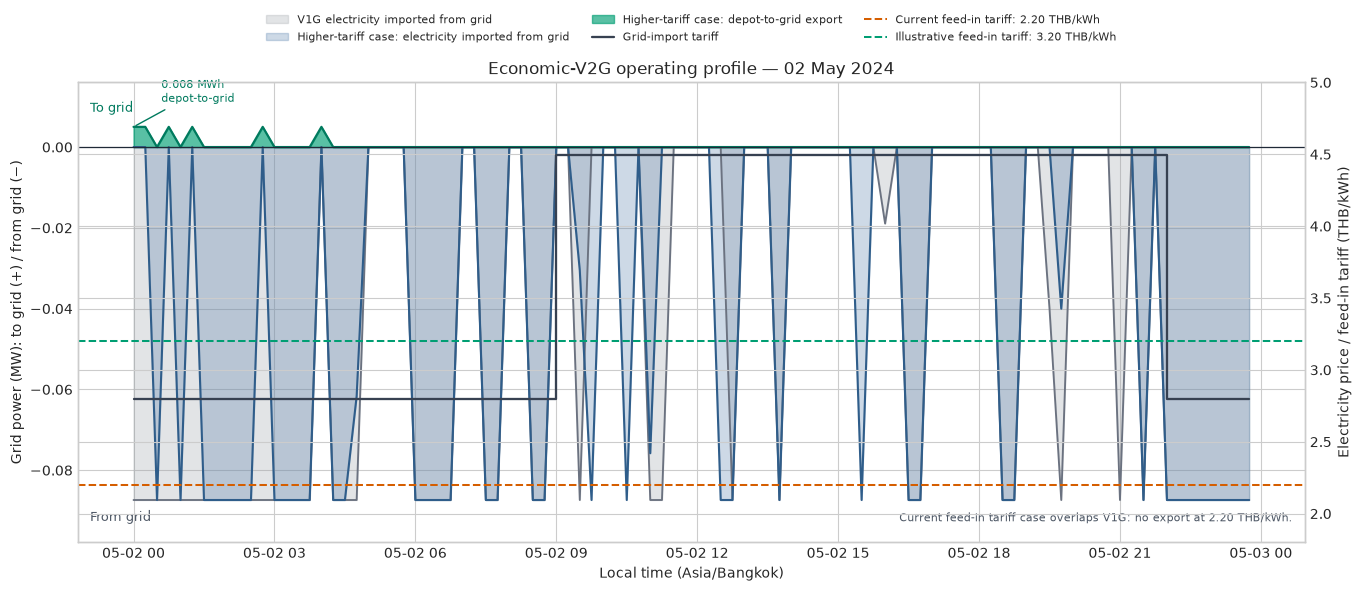

In [6]:
i01_label = 'V1G baseline'
i02a_label = 'I02a least-cost V2G at current feed-in tariff'
i02b_label = 'I02b economically viable V2G export'

required = [i01_label, i02a_label, i02b_label]
missing = [label for label in required if label not in dispatch_by_case or label not in comparison.index]
if missing:
    print(f'Missing completed economic-case outputs: {missing}')
else:
    i01 = dispatch_by_case[i01_label].copy()
    i02a = dispatch_by_case[i02a_label].copy()
    i02b = dispatch_by_case[i02b_label].copy()
    for frame in (i01, i02a, i02b):
        frame.index = pd.to_datetime(frame.index)

    # Illustrative normal working day with the greatest I02b depot-to-grid energy.
    daily_export = i02b['grid_export_MWh'].groupby(i02b.index.date).sum()
    holiday_by_day = forecast['is_public_holiday'].groupby(forecast.index.date).max()
    working_days = [day for day in daily_export.index if pd.Timestamp(day).weekday() < 5 and not bool(holiday_by_day.get(day, False))]
    selected_day = daily_export.loc[working_days].idxmax() if working_days else daily_export.idxmax()
    i01_day = i01.loc[i01.index.date == selected_day].copy()
    i02b_day = i02b.loc[i02b.index.date == selected_day].copy()
    export_day = i02b_day['grid_export_MWh'].sum()

    # Convention: electricity taken from the grid is below zero; electricity delivered
    # from the depot to the grid is above zero.
    i01_import_power = i01_day['grid_import_MWh'] / 0.25
    i02b_import_power = i02b_day['grid_import_MWh'] / 0.25
    i02b_export_power = i02b_day['grid_export_MWh'] / 0.25
    import_price = i02b_day['electricity_import_price_THB_per_MWh'] / 1000

    fig, power_axis = plt.subplots(figsize=(13.5, 5.8), constrained_layout=True)
    power_axis.fill_between(i01_day.index, -i01_import_power, 0, color='#9AA0A6', alpha=0.28, label='V1G electricity imported from grid')
    power_axis.plot(i01_day.index, -i01_import_power, color='#6B7280', linewidth=1.35)
    power_axis.fill_between(i02b_day.index, -i02b_import_power, 0, color='#4C78A8', alpha=0.28, label='Higher-tariff case: electricity imported from grid')
    power_axis.plot(i02b_day.index, -i02b_import_power, color='#2F5D8A', linewidth=1.5)
    power_axis.fill_between(i02b_day.index, 0, i02b_export_power, color='#009E73', alpha=0.65, label='Higher-tariff case: depot-to-grid export')
    power_axis.plot(i02b_day.index, i02b_export_power, color='#007A5E', linewidth=1.6)
    power_axis.axhline(0, color='#1F2937', linewidth=0.9)
    power_axis.set_ylabel('Grid power (MW): to grid (+) / from grid (−)')
    power_axis.set_xlabel('Local time (Asia/Bangkok)')
    power_axis.set_title(f'Economic-V2G operating profile — {pd.Timestamp(selected_day):%d %b %Y}')
    power_axis.text(0.01, 0.04, 'From grid', transform=power_axis.transAxes, color='#4B5563', fontsize=9, va='bottom')
    power_axis.text(0.01, 0.96, 'To grid', transform=power_axis.transAxes, color='#007A5E', fontsize=9, va='top')
    power_axis.set_ylim(-1.12 * max(i01_import_power.max(), i02b_import_power.max()), max(0.016, 1.6 * i02b_export_power.max()))

    tariff_axis = power_axis.twinx()
    tariff_axis.step(i02b_day.index, import_price, where='post', color='#374151', linewidth=1.65, label='Grid-import tariff')
    tariff_axis.axhline(2.20, color='#D55E00', linewidth=1.45, linestyle='--', label='Current feed-in tariff: 2.20 THB/kWh')
    tariff_axis.axhline(3.20, color='#009E73', linewidth=1.45, linestyle='--', label='Illustrative feed-in tariff: 3.20 THB/kWh')
    tariff_axis.set_ylabel('Electricity price / feed-in tariff (THB/kWh)')
    tariff_axis.set_ylim(1.8, 5.0)

    handles_1, labels_1 = power_axis.get_legend_handles_labels()
    handles_2, labels_2 = tariff_axis.get_legend_handles_labels()
    power_axis.legend(handles_1 + handles_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol=3, frameon=False, fontsize=8)
    power_axis.annotate(f'{export_day:.3f} MWh\ndepot-to-grid', xy=(i02b_day.index[i02b_export_power.argmax()], i02b_export_power.max()), xytext=(20, 18), textcoords='offset points', color='#007A5E', fontsize=8, arrowprops={'arrowstyle': '-', 'color': '#007A5E'})
    power_axis.text(0.99, 0.04, 'Current feed-in tariff case overlaps V1G: no export at 2.20 THB/kWh.', transform=power_axis.transAxes, ha='right', va='bottom', fontsize=8, color='#4B5563')
    plt.show()


findfont: Failed to find font weight semibold, now using 700.


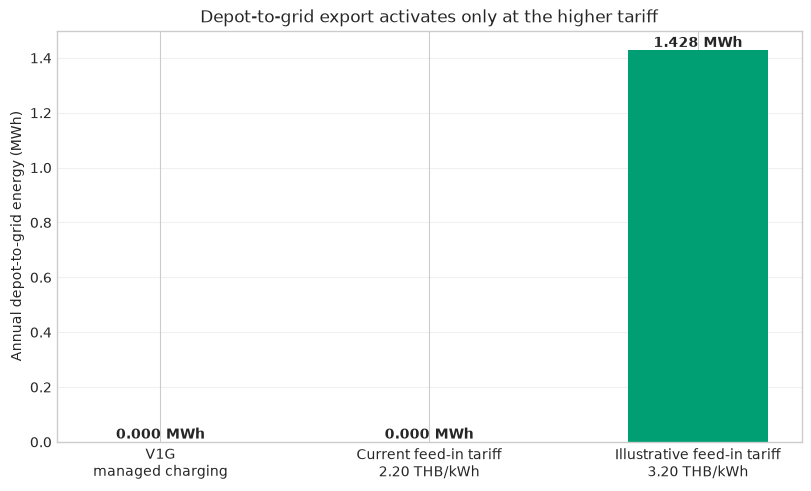

In [7]:
if not missing:
    cases = [i01_label, i02a_label, i02b_label]
    labels = ['V1G\nmanaged charging', 'Current feed-in tariff\n2.20 THB/kWh', 'Illustrative feed-in tariff\n3.20 THB/kWh']
    depot_to_grid_mwh = [float(dispatch_by_case[case]['grid_export_MWh'].sum()) for case in cases]
    peak_i02b_kw = float(dispatch_by_case[i02b_label]['grid_export_MWh'].max() / 0.25 * 1000)
    unmet_i02b = float(comparison.loc[i02b_label, 'unmet_trip_energy_MWh'])

    fig, axis = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
    bars = axis.bar(labels, depot_to_grid_mwh, color=['#9AA0A6', '#9AA0A6', '#009E73'], width=0.52)
    axis.set_ylabel('Annual depot-to-grid energy (MWh)')
    axis.set_title('Depot-to-grid export activates only at the higher tariff')
    axis.grid(axis='y', alpha=0.28)
    axis.set_axisbelow(True)
    for bar, value in zip(bars, depot_to_grid_mwh):
        axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.3f} MWh', ha='center', va='bottom', fontsize=10, fontweight='semibold')
    plt.show()


findfont: Failed to find font weight semibold, now using 700.


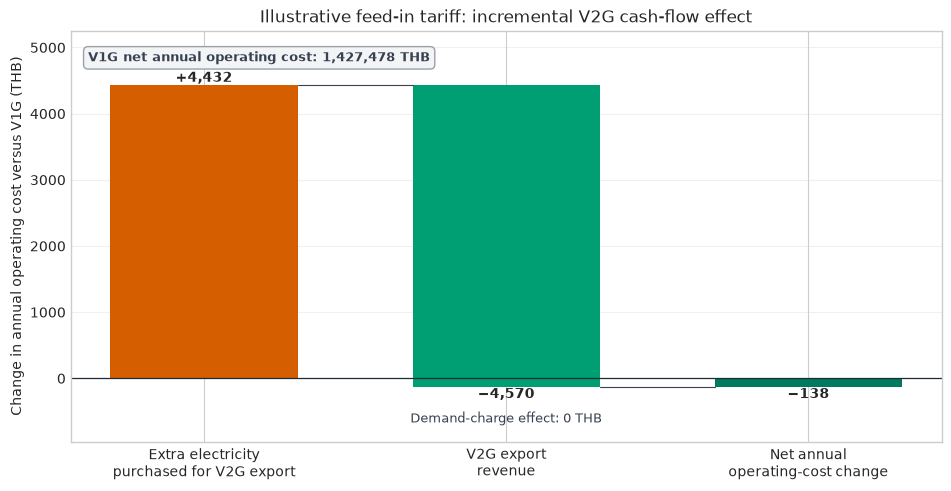

In [8]:
if not missing:
    def import_cost(frame):
        return float((frame['grid_import_MWh'] * frame['electricity_import_price_THB_per_MWh']).sum())

    def export_revenue(frame):
        return float((frame['grid_export_MWh'] * frame['electricity_export_price_THB_per_MWh']).sum())

    delta_import_cost = import_cost(i02b) - import_cost(i01)
    i02b_export_revenue = export_revenue(i02b)
    delta_demand_charge = comparison.loc[i02b_label, 'demand_charge_THB'] - comparison.loc[i01_label, 'demand_charge_THB']
    v1g_total_operating_cost = comparison.loc[i01_label, 'total_cost_THB']
    net_cost_change = comparison.loc[i02b_label, 'total_cost_THB'] - v1g_total_operating_cost

    names = ['Extra electricity\npurchased for V2G export', 'V2G export\nrevenue', 'Net annual\noperating-cost change']
    values = [delta_import_cost, -i02b_export_revenue, net_cost_change]
    bottoms = [0, delta_import_cost + values[1], min(0, net_cost_change)]
    heights = [delta_import_cost, abs(values[1]), abs(net_cost_change)]
    colors = ['#D55E00', '#009E73', '#007A5E']

    fig, axis = plt.subplots(figsize=(9.4, 4.8), constrained_layout=True)
    x = np.arange(3)
    axis.bar(x, heights, bottom=bottoms, color=colors, width=0.62)
    axis.plot([x[0] + 0.31, x[1] - 0.31], [delta_import_cost, delta_import_cost], color='#374151', linewidth=0.8)
    axis.plot([x[1] + 0.31, x[2] - 0.31], [net_cost_change, net_cost_change], color='#374151', linewidth=0.8)
    axis.axhline(0, color='#1F2937', linewidth=0.9)
    axis.set_xticks(x, names)
    axis.set_ylabel('Change in annual operating cost versus V1G (THB)')
    axis.set_title('Illustrative feed-in tariff: incremental V2G cash-flow effect')
    axis.grid(axis='y', alpha=0.28)
    axis.set_axisbelow(True)
    margin = max(delta_import_cost, i02b_export_revenue) * 0.18
    axis.set_ylim(min(net_cost_change - margin, -margin), max(delta_import_cost + margin, margin))
    label_y = [delta_import_cost, bottoms[1], net_cost_change]
    for xpos, value, ypos in zip(x, values, label_y):
        text = f'+{value:,.0f}' if value > 0 else f'−{abs(value):,.0f}' if value < 0 else '0'
        axis.text(xpos, ypos, text, ha='center', va='bottom' if value >= 0 else 'top', fontsize=10, fontweight='semibold')
    axis.text(0.02, 0.95, f'V1G net annual operating cost: {v1g_total_operating_cost:,.0f} THB', transform=axis.transAxes, ha='left', va='top', fontsize=9.5, fontweight='semibold', color='#374151', bbox={'boxstyle': 'round,pad=0.35', 'facecolor': '#F3F4F6', 'edgecolor': '#9AA0A6'})
    axis.text(0.5, 0.04, f'Demand-charge effect: {delta_demand_charge:,.0f} THB', transform=axis.transAxes, ha='center', va='bottom', fontsize=9, color='#374151')
    plt.show()


**Interpretation.** The current feed-in tariff does not induce export. The 3.20 THB/kWh point is not a tariff recommendation; it is the first tested value above the efficiency-based break-even estimate that induces marginal export.


## 5. Regional high-load import reduction


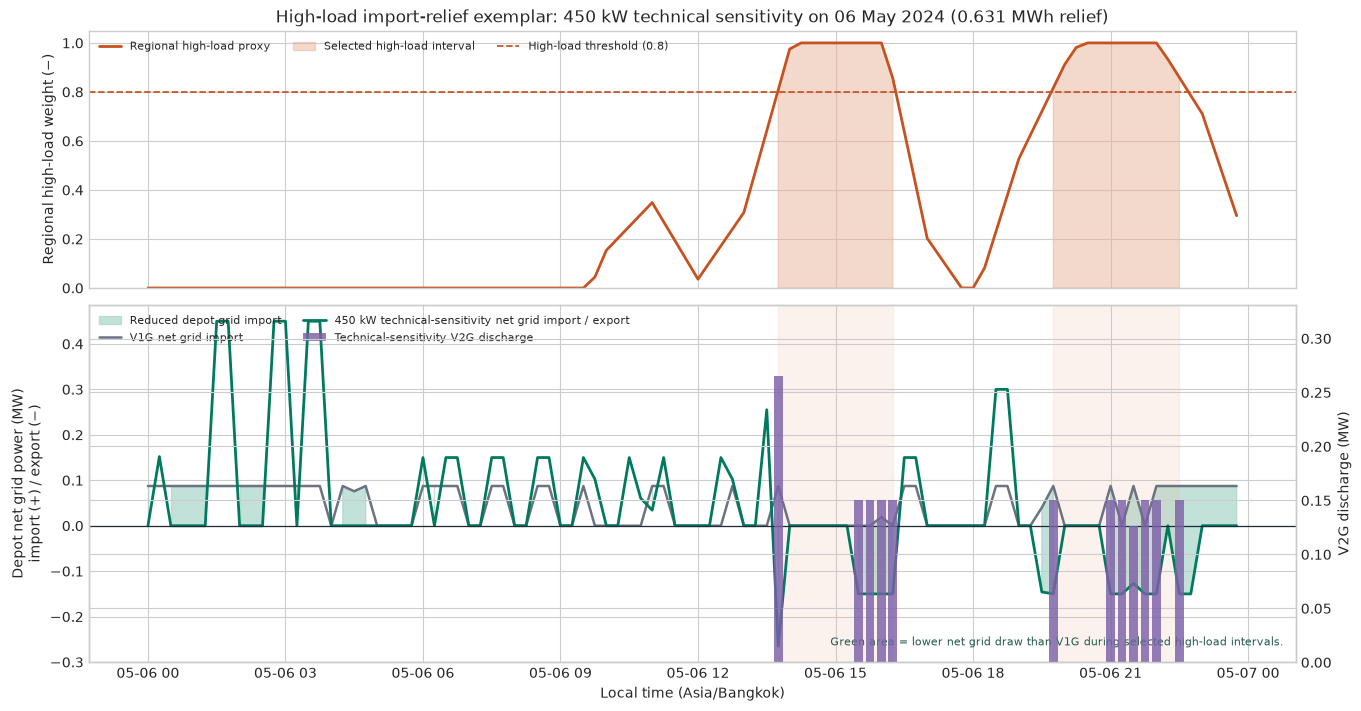

In [9]:
v1g_label = 'V1G baseline'
i04a_label = 'I04a maximum regional high-load import relief at 5 kW policy limit'
i04b_label = 'I04b maximum regional high-load import relief at 450 kW technical sensitivity'

high_load_cases = [v1g_label, i04a_label, i04b_label]
missing_high_load = [label for label in high_load_cases if label not in dispatch_by_case or label not in comparison.index]
if missing_high_load:
    print(f'Missing completed high-load-case outputs: {missing_high_load}')
else:
    v1g_dispatch = dispatch_by_case[v1g_label].copy()
    i04b_dispatch = dispatch_by_case[i04b_label].copy()
    for frame in (v1g_dispatch, i04b_dispatch):
        frame.index = pd.to_datetime(frame.index)

    common_index = v1g_dispatch.index.intersection(i04b_dispatch.index)
    v1g_profile = v1g_dispatch.loc[common_index]
    i04b_profile = i04b_dispatch.loc[common_index]
    threshold = float(i04b_profile['grid_stress_threshold'].iloc[0])
    high_load = i04b_profile['grid_congestion_weight'] >= threshold
    relief_mwh = v1g_profile['traction_net_grid_import_MWh'] - i04b_profile['traction_net_grid_import_MWh']
    daily_relief = relief_mwh.where(high_load, 0.0).groupby(relief_mwh.index.date).sum()
    selected_day = daily_relief.idxmax()

    v1g_day = v1g_profile.loc[v1g_profile.index.date == selected_day].copy()
    i04b_day = i04b_profile.loc[i04b_profile.index.date == selected_day].copy()
    high_load_day = i04b_day['grid_congestion_weight'] >= threshold
    relief_day_mwh = v1g_day['traction_net_grid_import_MWh'] - i04b_day['traction_net_grid_import_MWh']
    relief_day = float(relief_day_mwh.where(high_load_day, 0.0).sum())

    v1g_power = v1g_day['traction_net_grid_import_MWh'] / 0.25
    i04b_power = i04b_day['traction_net_grid_import_MWh'] / 0.25
    v2g_discharge = i04b_day['bus_discharge_MWh'] / 0.25

    fig, (signal_axis, power_axis) = plt.subplots(2, 1, figsize=(13.5, 7.0), sharex=True, constrained_layout=True, height_ratios=[0.9, 1.25])
    signal_axis.plot(i04b_day.index, i04b_day['grid_congestion_weight'], color='#C7511F', linewidth=2.0, label='Regional high-load proxy')
    signal_axis.fill_between(i04b_day.index, 0, i04b_day['grid_congestion_weight'], where=high_load_day, color='#E8B49A', alpha=0.5, label='Selected high-load interval')
    signal_axis.axhline(threshold, color='#C7511F', linewidth=1.25, linestyle='--', label=f'High-load threshold ({threshold:.1f})')
    signal_axis.set_ylim(0, 1.05)
    signal_axis.set_ylabel('Regional high-load weight (−)')
    signal_axis.set_title(f'High-load import-relief exemplar: 450 kW technical sensitivity on {pd.Timestamp(selected_day):%d %b %Y} ({relief_day:.3f} MWh relief)')
    signal_axis.legend(loc='upper left', ncol=3, frameon=False, fontsize=8)

    power_axis.fill_between(v1g_day.index, v1g_power, i04b_power, where=(v1g_power > i04b_power), color='#A8D5C9', alpha=0.7, label='Reduced depot grid import')
    power_axis.plot(v1g_day.index, v1g_power, color='#6B7280', linewidth=1.8, label='V1G net grid import')
    power_axis.plot(i04b_day.index, i04b_power, color='#007A5E', linewidth=2.0, label='450 kW technical-sensitivity net grid import / export')
    power_axis.axhline(0, color='#1F2937', linewidth=0.9)
    power_axis.set_ylabel('Depot net grid power (MW)\nimport (+) / export (−)')
    power_axis.set_xlabel('Local time (Asia/Bangkok)')
    power_axis.fill_between(i04b_day.index, 0, 1, where=high_load_day, transform=power_axis.get_xaxis_transform(), color='#E8B49A', alpha=0.16)

    discharge_axis = power_axis.twinx()
    discharge_axis.bar(i04b_day.index, v2g_discharge.where(high_load_day, 0.0), width=0.008, color='#7B61A8', alpha=0.82, label='Technical-sensitivity V2G discharge')
    discharge_axis.set_ylim(0, max(0.05, float(v2g_discharge.max()) * 1.25))
    discharge_axis.set_ylabel('V2G discharge (MW)')

    handles_1, labels_1 = power_axis.get_legend_handles_labels()
    handles_2, labels_2 = discharge_axis.get_legend_handles_labels()
    power_axis.legend(handles_1 + handles_2, labels_1 + labels_2, loc='upper left', ncol=2, frameon=False, fontsize=8)
    power_axis.text(0.99, 0.04, 'Green area = lower net grid draw than V1G during selected high-load intervals.', transform=power_axis.transAxes, ha='right', va='bottom', fontsize=8, color='#245B4F')
    plt.show()


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


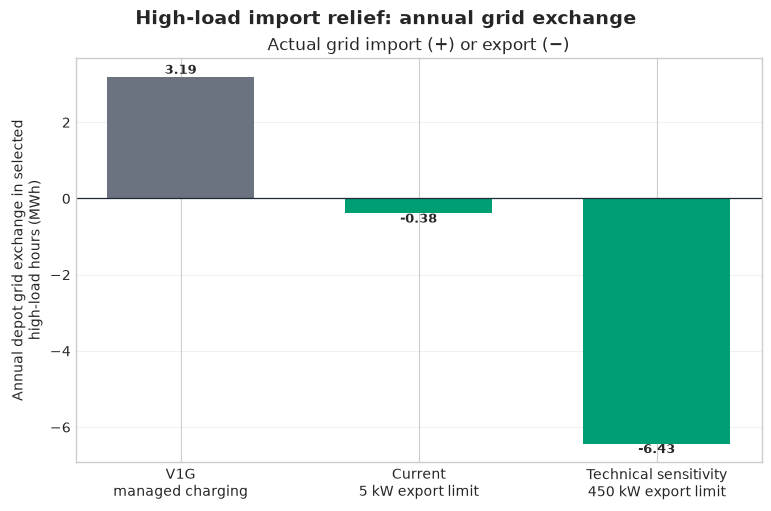

In [10]:
if not missing_high_load:
    def high_load_metrics(case_label):
        case = dispatch_by_case[case_label]
        base = dispatch_by_case[v1g_label]
        common = base.index.intersection(case.index)
        base = base.loc[common]
        case = case.loc[common]
        case_high_load = case['grid_congestion_weight'] >= float(case['grid_stress_threshold'].iloc[0])
        base_net = base['traction_net_grid_import_MWh']
        case_net = case['traction_net_grid_import_MWh']
        relief = base_net - case_net
        return {
            'high_load_net_exchange_MWh': float(case_net.where(case_high_load, 0.0).sum()),
            'high_load_import_relief_MWh': float(relief.where(case_high_load, 0.0).sum()),
            'peak_import_relief_kW': float(relief.max() / 0.25 * 1000),
        }

    metric_rows = {label: high_load_metrics(label) for label in high_load_cases}
    high_load_summary = pd.DataFrame(metric_rows).T
    labels = ['V1G\nmanaged charging', 'Current\n5 kW export limit', 'Technical sensitivity\n450 kW export limit']
    x = np.arange(len(high_load_cases))
    exchanges = high_load_summary['high_load_net_exchange_MWh'].to_numpy()
    exchange_colors = ['#6B7280' if value > 0 else '#009E73' for value in exchanges]

    fig, exchange_axis = plt.subplots(figsize=(7.6, 5.0), constrained_layout=True)
    bars = exchange_axis.bar(x, exchanges, color=exchange_colors, width=0.62)
    exchange_axis.axhline(0, color='#1F2937', linewidth=0.9)
    exchange_axis.set_xticks(x, labels)
    exchange_axis.set_ylabel('Annual depot grid exchange in selected\nhigh-load hours (MWh)')
    exchange_axis.set_title('Actual grid import (+) or export (−)')
    exchange_axis.grid(axis='y', alpha=0.28)
    exchange_axis.set_axisbelow(True)
    for bar, value in zip(bars, exchanges):
        exchange_axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.2f}', ha='center', va='bottom' if value >= 0 else 'top', fontsize=9, fontweight='semibold')
    fig.suptitle('High-load import relief: annual grid exchange', fontsize=14, fontweight='semibold')
    plt.show()


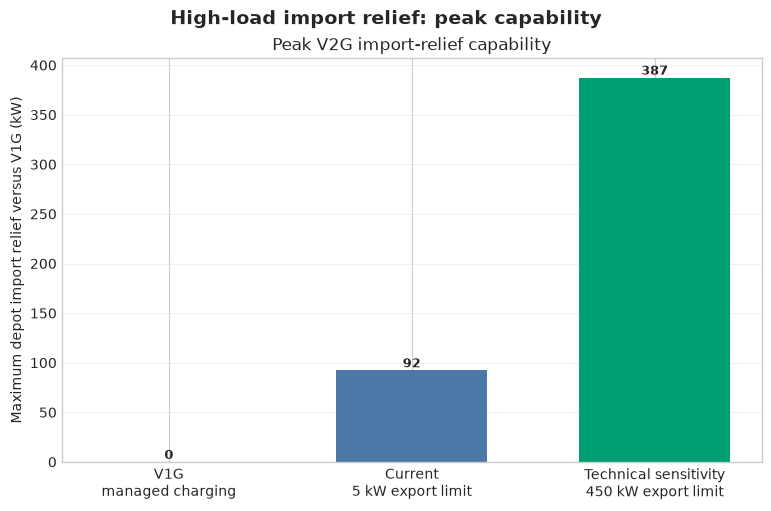

In [11]:
if not missing_high_load:
    peak_relief = high_load_summary['peak_import_relief_kW'].to_numpy()
    fig, relief_axis = plt.subplots(figsize=(7.6, 5.0), constrained_layout=True)
    bars = relief_axis.bar(x, peak_relief, color=['#9AA0A6', '#4C78A8', '#009E73'], width=0.62)
    relief_axis.set_xticks(x, labels)
    relief_axis.set_ylabel('Maximum depot import relief versus V1G (kW)')
    relief_axis.set_title('Peak V2G import-relief capability')
    relief_axis.grid(axis='y', alpha=0.28)
    relief_axis.set_axisbelow(True)
    for bar, value in zip(bars, peak_relief):
        relief_axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.0f}', ha='center', va='bottom', fontsize=9, fontweight='semibold')
    fig.suptitle('High-load import relief: peak capability', fontsize=14, fontweight='semibold')
    plt.show()


findfont: Failed to find font weight semibold, now using 700.


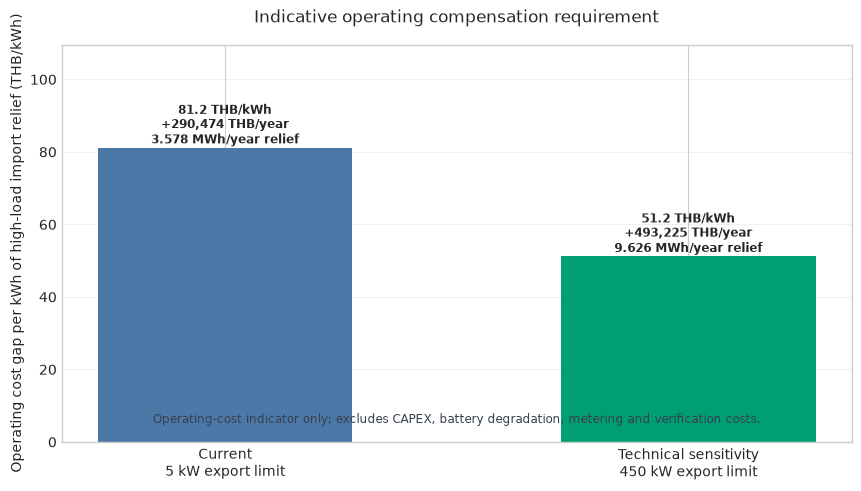

In [12]:
if not missing_high_load:
    compensation = []
    for label in [i04a_label, i04b_label]:
        relief_mwh = high_load_summary.loc[label, 'high_load_import_relief_MWh']
        cost_gap = comparison.loc[label, 'total_cost_THB'] - comparison.loc[v1g_label, 'total_cost_THB']
        compensation.append({
            'case': label,
            'cost_gap_THB': cost_gap,
            'relief_MWh': relief_mwh,
            'cost_gap_THB_per_kWh': cost_gap / (relief_mwh * 1000) if relief_mwh > 0 else np.nan,
        })
    compensation = pd.DataFrame(compensation).set_index('case')
    labels = ['Current\n5 kW export limit', 'Technical sensitivity\n450 kW export limit']
    values = compensation['cost_gap_THB_per_kWh'].to_numpy()

    fig, axis = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
    bars = axis.bar(labels, values, color=['#4C78A8', '#009E73'], width=0.55)
    axis.set_ylabel('Operating cost gap per kWh of high-load import relief (THB/kWh)')
    axis.set_title('Indicative operating compensation requirement', pad=16)
    axis.set_ylim(0, max(values) * 1.35)
    axis.grid(axis='y', alpha=0.28)
    axis.set_axisbelow(True)
    for bar, case, value in zip(bars, compensation.index, values):
        annual_gap = compensation.loc[case, 'cost_gap_THB']
        relief = compensation.loc[case, 'relief_MWh']
        axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.1f} THB/kWh\n+{annual_gap:,.0f} THB/year\n{relief:.3f} MWh/year relief', ha='center', va='bottom', fontsize=8.5, fontweight='semibold')
    axis.text(0.5, 0.04, 'Operating-cost indicator only; excludes CAPEX, battery degradation, metering and verification costs.', transform=axis.transAxes, ha='center', va='bottom', fontsize=8.5, color='#374151')
    plt.show()


In [13]:
# Complete high-load family, including the no-export V2G case.
family = [
    ('I03 maximum regional high-load import relief without export', 'No-export V2G'),
    ('I04a maximum regional high-load import relief at 5 kW policy limit', 'Current 5 kW export limit'),
    ('I04b maximum regional high-load import relief at 450 kW technical sensitivity', '450 kW technical sensitivity'),
]
rows = []
if 'V1G baseline' in dispatch_by_case:
    baseline = dispatch_by_case['V1G baseline']
    for scenario, name in family:
        if scenario not in dispatch_by_case:
            continue
        dispatch = dispatch_by_case[scenario]
        common = baseline.index.intersection(dispatch.index)
        high_load = dispatch.loc[common, 'grid_congestion_weight'] >= dispatch.loc[common, 'grid_stress_threshold']
        relief = baseline.loc[common, 'traction_net_grid_import_MWh'] - dispatch.loc[common, 'traction_net_grid_import_MWh']
        rows.append({
            'Scenario': name,
            'High-load import relief (MWh/year)': float(relief.loc[high_load].sum()),
            'Peak relief (kW)': float(relief.max() / 0.25 * 1000),
            'Operating cost gap (THB/kWh)': float(comparison.loc[scenario, 'total_cost_THB'] - comparison.loc['V1G baseline', 'total_cost_THB']) / (float(relief.loc[high_load].sum()) * 1000),
        })
if rows:
    high_load_family = pd.DataFrame(rows).set_index('Scenario')
    display(high_load_family.round(3))


,High-load import relief (MWh/year),Peak relief (kW),Operating cost gap (THB/kWh)
Scenario,,,
No-export V2G,3.194,87.368,85.822
Current 5 kW export limit,3.578,92.368,81.190
450 kW technical sensitivity,9.626,387.368,51.238


**Interpretation.** The high-load signal is a conditional regional demand proxy. The 450 kW result is a technical sensitivity, not an approved export capacity. The operating-cost gap is an indicator of the compensation required if a local service is defined and procured.


## 6. Renewable-responsive operation


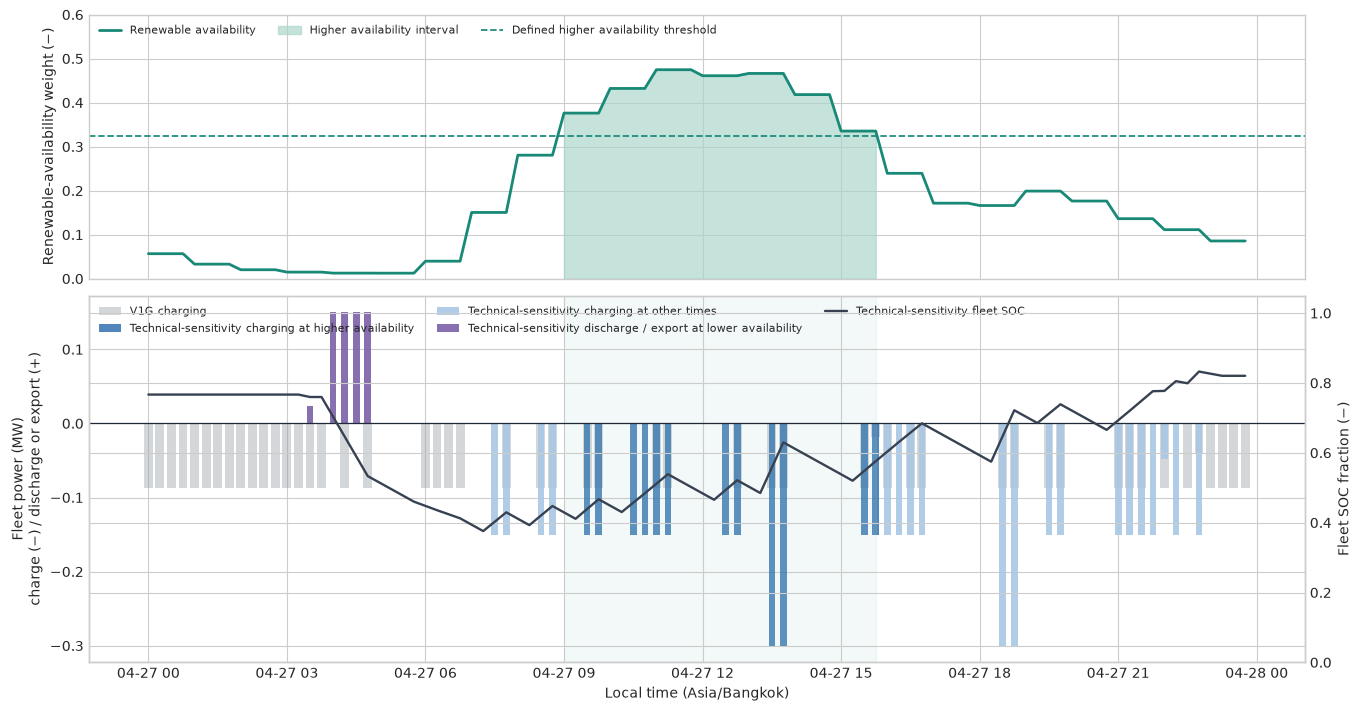

In [14]:
i06a_label = 'I06a maximum renewable-deficit support at 5 kW policy limit'
i06b_label = 'I06b maximum renewable-deficit support at 450 kW technical sensitivity'
renewable_cases = [v1g_label, i06a_label, i06b_label]
missing_renewable = [label for label in renewable_cases if label not in dispatch_by_case or label not in comparison.index]

if missing_renewable:
    print(f'Missing completed renewable-alignment outputs: {missing_renewable}')
else:
    renewable_signal = pd.read_csv(
        INPUT_ROOT / 'building_v2b_renewable_alignment_annual' / 'forecasts_df.csv',
        usecols=['datetime', 'renewable_availability_weight', 'renewable_rich_threshold'],
        parse_dates=['datetime'],
    ).set_index('datetime')
    renewable_signal.index = renewable_signal.index.tz_localize(dispatch_by_case[v1g_label].index.tz)
    renewable_threshold = float(renewable_signal['renewable_rich_threshold'].iloc[0])

    # Use the previously identified illustrative April day; it contains both
    # higher and lower availability intervals and visible I06b discharge.
    selected_day = pd.Timestamp('2024-04-27', tz=dispatch_by_case[v1g_label].index.tz).date()
    v1g_day = dispatch_by_case[v1g_label].loc[dispatch_by_case[v1g_label].index.date == selected_day].copy()
    i06b_day = dispatch_by_case[i06b_label].loc[dispatch_by_case[i06b_label].index.date == selected_day].copy()
    signal_day = renewable_signal.reindex(i06b_day.index)
    higher_availability = signal_day['renewable_availability_weight'] >= renewable_threshold
    weighted_discharge_day = float((i06b_day['bus_discharge_MWh'] * (1 - signal_day['renewable_availability_weight'])).sum())

    v1g_charge_power = v1g_day['bus_charge_MWh'] / 0.25
    i06b_charge_power = i06b_day['bus_charge_MWh'] / 0.25
    i06b_discharge_power = i06b_day['bus_discharge_MWh'] / 0.25
    i06b_soc = i06b_day['bus_soc_fraction']

    fig, (signal_axis, action_axis) = plt.subplots(2, 1, figsize=(13.5, 7.0), sharex=True, constrained_layout=True, height_ratios=[0.9, 1.25])
    signal_axis.plot(signal_day.index, signal_day['renewable_availability_weight'], color='#188977', linewidth=2.0, label='Renewable availability')
    signal_axis.fill_between(signal_day.index, 0, signal_day['renewable_availability_weight'], where=higher_availability, color='#A8D5C9', alpha=0.65, label='Higher availability interval')
    signal_axis.axhline(renewable_threshold, color='#188977', linewidth=1.25, linestyle='--', label='Defined higher availability threshold')
    signal_axis.set_ylim(0, max(0.6, float(signal_day['renewable_availability_weight'].max()) * 1.12))
    signal_axis.set_ylabel('Renewable-availability weight (−)')
    # signal_axis.set_title(f'Renewable-alignment exemplar: I06b on {pd.Timestamp(selected_day):%d %b %Y} ({weighted_discharge_day:.3f} MWh proxy-weighted discharge)')
    signal_axis.legend(loc='upper left', ncol=3, frameon=False, fontsize=8)

    action_axis.bar(v1g_day.index, -v1g_charge_power, width=0.008, color='#9AA0A6', alpha=0.42, label='V1G charging')
    action_axis.bar(i06b_day.index, -i06b_charge_power.where(higher_availability, 0.0), width=0.006, color='#2F6FB0', alpha=0.84, label='Technical-sensitivity charging at higher availability')
    action_axis.bar(i06b_day.index, -i06b_charge_power.where(~higher_availability, 0.0), width=0.006, color='#A8C7E5', alpha=0.9, label='Technical-sensitivity charging at other times')
    action_axis.bar(i06b_day.index, i06b_discharge_power.where(~higher_availability, 0.0), width=0.006, color='#7B61A8', alpha=0.9, label='Technical-sensitivity discharge / export at lower availability')
    action_axis.axhline(0, color='#1F2937', linewidth=0.9)
    action_axis.set_ylabel('Fleet power (MW)\ncharge (−) / discharge or export (+)')
    action_axis.set_xlabel('Local time (Asia/Bangkok)')
    action_axis.fill_between(i06b_day.index, 0, 1, where=higher_availability, transform=action_axis.get_xaxis_transform(), color='#A8D5C9', alpha=0.13)

    soc_axis = action_axis.twinx()
    soc_axis.plot(i06b_day.index, i06b_soc, color='#374151', linewidth=1.7, label='Technical-sensitivity fleet SOC')
    soc_axis.set_ylim(0, 1.05)
    soc_axis.set_ylabel('Fleet SOC fraction (−)')
    handles_1, labels_1 = action_axis.get_legend_handles_labels()
    handles_2, labels_2 = soc_axis.get_legend_handles_labels()
    action_axis.legend(handles_1 + handles_2, labels_1 + labels_2, loc='upper left', ncol=3, frameon=False, fontsize=8)
    plt.show()


findfont: Failed to find font weight semibold, now using 700.


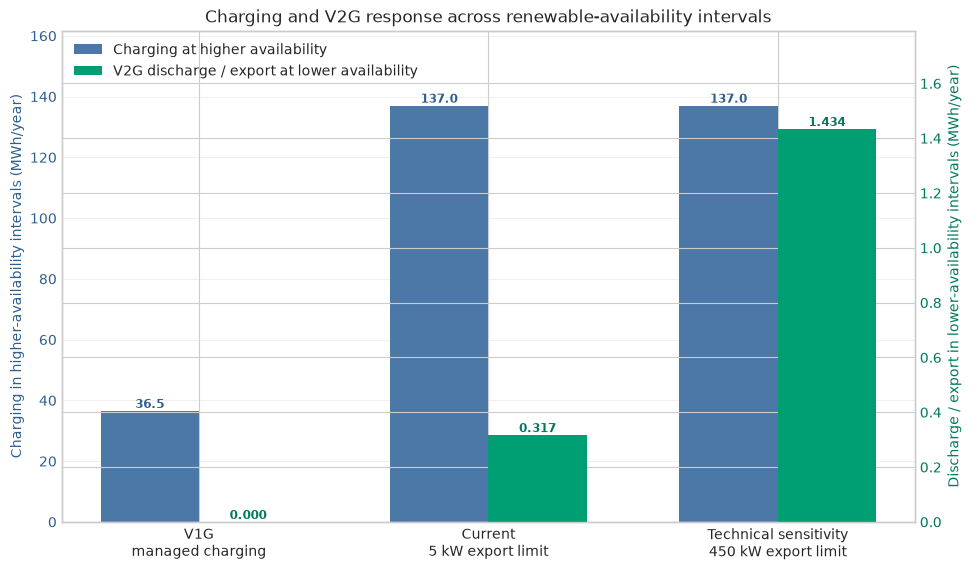

In [15]:
if not missing_renewable:
    def renewable_metrics(case_label):
        dispatch = dispatch_by_case[case_label]
        signal = renewable_signal.reindex(dispatch.index)
        higher = signal['renewable_availability_weight'] >= renewable_threshold
        lower = ~higher
        return {
            'charge_higher_availability_MWh': float(dispatch.loc[higher, 'bus_charge_MWh'].sum()),
            'depot_to_grid_lower_availability_MWh': float(dispatch.loc[lower, 'grid_export_MWh'].sum()),
        }

    renewable_summary = pd.DataFrame({label: renewable_metrics(label) for label in renewable_cases}).T
    display_labels = ['V1G\nmanaged charging', 'Current\n5 kW export limit', 'Technical sensitivity\n450 kW export limit']
    x = np.arange(len(renewable_cases))
    charge_values = renewable_summary['charge_higher_availability_MWh'].to_numpy()
    export_values = renewable_summary['depot_to_grid_lower_availability_MWh'].to_numpy()
    width = 0.34

    fig, charge_axis = plt.subplots(figsize=(9.6, 5.6), constrained_layout=True)
    export_axis = charge_axis.twinx()
    charge_bars = charge_axis.bar(x - width / 2, charge_values, width, color='#4C78A8', label='Charging at higher availability')
    export_bars = export_axis.bar(x + width / 2, export_values, width, color='#009E73', label='V2G discharge / export at lower availability')
    charge_axis.set_xticks(x, display_labels)
    charge_axis.set_ylabel('Charging in higher-availability intervals (MWh/year)', color='#2F5F8E')
    export_axis.set_ylabel('Discharge / export in lower-availability intervals (MWh/year)', color='#00795F')
    charge_axis.tick_params(axis='y', colors='#2F5F8E')
    export_axis.tick_params(axis='y', colors='#00795F')
    charge_axis.set_title('Charging and V2G response across renewable-availability intervals')
    charge_axis.grid(axis='y', alpha=0.28)
    charge_axis.set_axisbelow(True)
    charge_axis.set_ylim(0, charge_values.max() * 1.18)
    export_axis.set_ylim(0, max(export_values.max() * 1.25, 0.2))
    for bar, value in zip(charge_bars, charge_values):
        charge_axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.1f}', ha='center', va='bottom', fontsize=8.8, fontweight='semibold', color='#2F5F8E')
    for bar, value in zip(export_bars, export_values):
        export_axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.3f}', ha='center', va='bottom', fontsize=8.8, fontweight='semibold', color='#00795F')
    handles = [charge_bars, export_bars]
    charge_axis.legend(handles, [handle.get_label() for handle in handles], loc='upper left', frameon=False)
    # fig.suptitle('', fontsize=14, fontweight='semibold')
    plt.show()


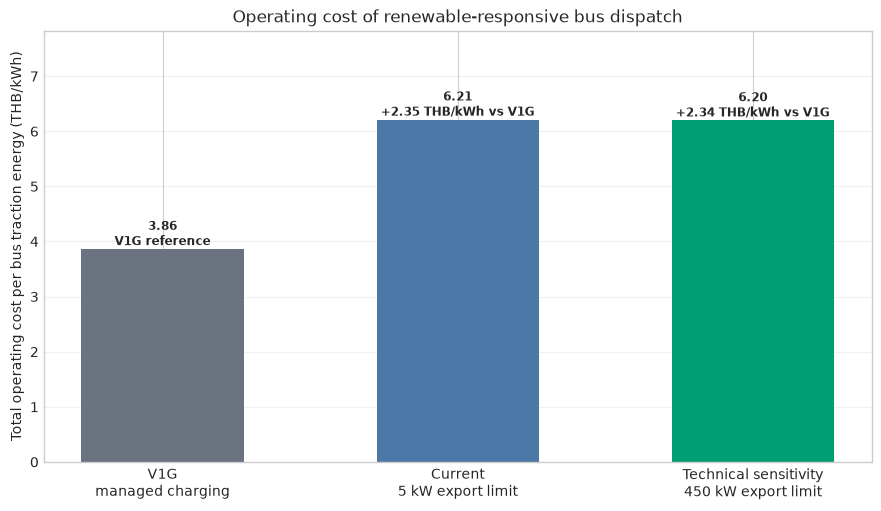

In [16]:
if not missing_renewable:
    cost_rows = []
    for label in renewable_cases:
        trip_energy_mwh = float(dispatch_by_case[label]['bus_trip_energy_MWh'].sum())
        cost_rows.append({
            'case': label,
            'trip_energy_MWh': trip_energy_mwh,
            'total_cost_THB': float(comparison.loc[label, 'total_cost_THB']),
            'operating_cost_THB_per_traction_kWh': float(comparison.loc[label, 'total_cost_THB']) / (trip_energy_mwh * 1000),
        })
    renewable_operator_cost = pd.DataFrame(cost_rows).set_index('case')
    reference_cost = renewable_operator_cost.loc[v1g_label, 'operating_cost_THB_per_traction_kWh']
    renewable_operator_cost['additional_cost_vs_V1G_THB_per_traction_kWh'] = (
        renewable_operator_cost['operating_cost_THB_per_traction_kWh'] - reference_cost
    )
    labels = ['V1G\nmanaged charging', 'Current\n5 kW export limit', 'Technical sensitivity\n450 kW export limit']
    values = renewable_operator_cost['operating_cost_THB_per_traction_kWh'].to_numpy()

    fig, axis = plt.subplots(figsize=(8.7, 5.0), constrained_layout=True)
    bars = axis.bar(labels, values, color=['#6B7280', '#4C78A8', '#009E73'], width=0.55)
    axis.set_ylabel('Total operating cost per bus traction energy (THB/kWh)')
    axis.set_title('Operating cost of renewable-responsive bus dispatch')
    axis.set_ylim(0, max(values) * 1.26)
    axis.grid(axis='y', alpha=0.28)
    axis.set_axisbelow(True)
    for bar, case, value in zip(bars, renewable_operator_cost.index, values):
        delta = renewable_operator_cost.loc[case, 'additional_cost_vs_V1G_THB_per_traction_kWh']
        suffix = 'V1G reference' if case == v1g_label else f'+{delta:.2f} THB/kWh vs V1G'
        axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.2f}\n{suffix}', ha='center', va='bottom', fontsize=8.5, fontweight='semibold')
    plt.show()


**Interpretation.** Renewable-responsive dispatch changes timing against an availability proxy. It is not a traced-renewable or least-cost result; a practical service requires an agreed signal, verification, and settlement.


In [17]:
# Complete renewable-responsive family, including the no-export case.
family = [
    ('I05 maximum renewable-deficit support without export', 'No-export response'),
    ('I06a maximum renewable-deficit support at 5 kW policy limit', 'Current 5 kW export limit'),
    ('I06b maximum renewable-deficit support at 450 kW technical sensitivity', '450 kW technical sensitivity'),
]
rows = []
for scenario, name in family:
    if scenario not in dispatch_by_case:
        continue
    dispatch = dispatch_by_case[scenario]
    rich = dispatch['renewable_availability_weight'] >= dispatch['renewable_rich_threshold']
    trip_energy = float(dispatch['bus_trip_energy_MWh'].sum())
    rows.append({
        'Scenario': name,
        'Charging at higher availability (MWh/year)': float(dispatch.loc[rich, 'bus_charge_MWh'].sum()),
        'Export at lower availability (MWh/year)': float(dispatch.loc[~rich, 'grid_export_MWh'].sum()),
        'Operating cost (THB/kWh traction)': float(comparison.loc[scenario, 'total_cost_THB']) / (trip_energy * 1000),
    })
if rows:
    renewable_family = pd.DataFrame(rows).set_index('Scenario')
    display(renewable_family.round(3))


,Charging at higher availability (MWh/year),Export at lower availability (MWh/year),Operating cost (THB/kWh traction)
Scenario,,,
No-export response,137.024,0.000,6.185
Current 5 kW export limit,137.025,0.317,6.211
450 kW technical sensitivity,137.024,1.434,6.197


## 7. Rooftop PV operation and high-load demand management


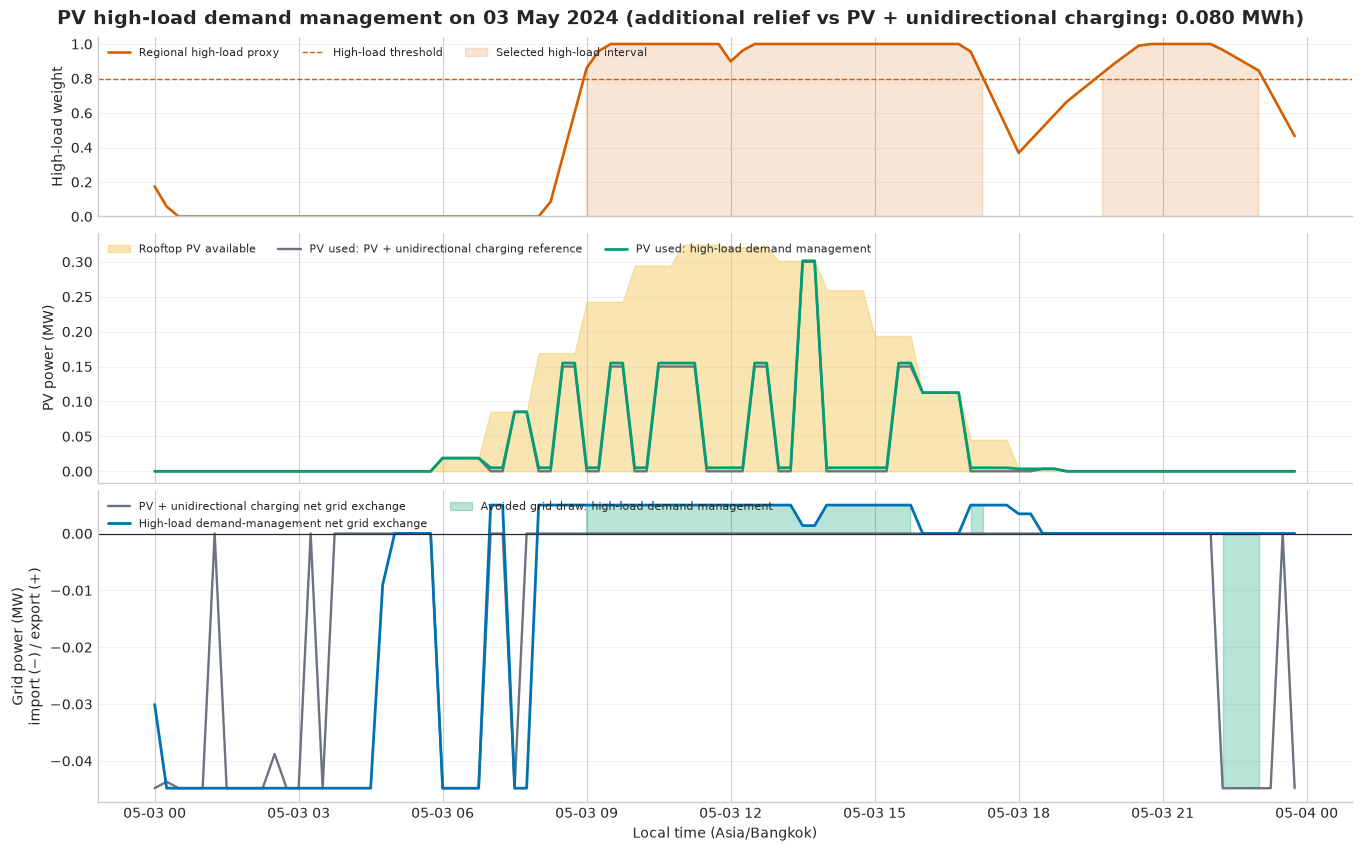

In [18]:
v1g_label = 'V1G baseline'
pv_only_label = 'PV + unidirectional charging reference'
i07b_label = 'I07b rooftop PV operation at current export policy'
i07d_label = 'I07d PV with high-load demand management'
pv_profile_cases = [pv_only_label, i07d_label]
missing_pv_profile = [label for label in pv_profile_cases if label not in dispatch_by_case or label not in comparison.index]
high_load_pv_available = i07d_label in dispatch_by_case and i07d_label in comparison.index

if missing_pv_profile:
    print(f'Missing completed rooftop-PV outputs: {missing_pv_profile}')
else:
    # Choose the day with the largest additional high-load-period relief from
    # I07d relative to PV + unidirectional charging.
    pv_only_dispatch = dispatch_by_case[pv_only_label]
    i07d_dispatch = dispatch_by_case[i07d_label]
    high_load = i07d_dispatch['grid_congestion_weight'] >= i07d_dispatch['grid_stress_threshold']
    pv_only_net = pv_only_dispatch['traction_net_grid_import_MWh']
    i07d_net = i07d_dispatch['traction_net_grid_import_MWh']
    relief = (pv_only_net - i07d_net).where(high_load, 0.0)
    daily_relief = relief.groupby(relief.index.normalize()).sum()
    selected_day = daily_relief.idxmax()
    day_mask = i07d_dispatch.index.normalize() == selected_day
    pv_only_day = pv_only_dispatch.loc[day_mask].copy()
    i07d_day = i07d_dispatch.loc[day_mask].copy()
    day_high_load = high_load.loc[day_mask]
    day_relief_mwh = float(relief.loc[day_mask].sum())

    pv_available_mw = i07d_day['pv_available_generation_MWh'] / 0.25
    pv_only_used_mw = pv_only_day['pv_generation_MWh'] / 0.25
    i07d_used_mw = i07d_day['pv_generation_MWh'] / 0.25
    high_load_signal = i07d_day['grid_congestion_weight']
    high_load_threshold = float(i07d_day['grid_stress_threshold'].iloc[0])
    pv_only_grid_power = -pv_only_day['traction_net_grid_import_MWh'] / 0.25
    i07d_grid_power = -i07d_day['traction_net_grid_import_MWh'] / 0.25
    import_relief = i07d_grid_power - pv_only_grid_power

    fig, axes = plt.subplots(3, 1, figsize=(13.5, 8.4), sharex=True, constrained_layout=True,
                             height_ratios=[0.72, 1.0, 1.25])
    signal_axis, pv_axis, exchange_axis = axes

    signal_axis.plot(i07d_day.index, high_load_signal, color='#D55E00', linewidth=1.9,
                     label='Regional high-load proxy')
    signal_axis.axhline(high_load_threshold, color='#D55E00', linestyle='--', linewidth=1.0,
                        label='High-load threshold')
    signal_axis.fill_between(i07d_day.index, 0, high_load_signal, where=day_high_load,
                             color='#D55E00', alpha=0.16, label='Selected high-load interval')
    signal_axis.set_ylim(0, 1.04)
    signal_axis.set_ylabel('High-load weight')
    signal_axis.legend(loc='upper left', ncol=3, frameon=False, fontsize=8)

    pv_axis.fill_between(i07d_day.index, 0, pv_available_mw, color='#F4C95D', alpha=0.48,
                         label='Rooftop PV available')
    pv_axis.plot(pv_only_day.index, pv_only_used_mw, color='#6B7280', linewidth=1.7,
                 label='PV used: PV + unidirectional charging reference')
    pv_axis.plot(i07d_day.index, i07d_used_mw, color='#009E73', linewidth=2.0,
                 label='PV used: high-load demand management')
    pv_axis.set_ylabel('PV power (MW)')
    pv_axis.legend(loc='upper left', ncol=3, frameon=False, fontsize=8)

    exchange_axis.plot(pv_only_day.index, pv_only_grid_power, color='#6B7280', linewidth=1.7,
                       label='PV + unidirectional charging net grid exchange')
    exchange_axis.plot(i07d_day.index, i07d_grid_power, color='#0072B2', linewidth=2.0,
                       label='High-load demand-management net grid exchange')
    exchange_axis.fill_between(i07d_day.index, pv_only_grid_power, i07d_grid_power,
                               where=day_high_load & (import_relief > 1e-9), color='#009E73',
                               alpha=0.28, label='Avoided grid draw: high-load demand management')
    exchange_axis.axhline(0, color='#1F2937', linewidth=0.9)
    exchange_axis.set_ylabel('Grid power (MW)\nimport (−) / export (+)')
    exchange_axis.set_xlabel('Local time (Asia/Bangkok)')
    exchange_axis.legend(loc='upper left', ncol=2, frameon=False, fontsize=8)

    for axis in axes:
        axis.grid(axis='y', alpha=0.25)
        axis.set_axisbelow(True)
        axis.spines[['top', 'right']].set_visible(False)
    fig.suptitle(
        f'PV high-load demand management on {selected_day:%d %B %Y} '
        f'(additional relief vs PV + unidirectional charging: {day_relief_mwh:.3f} MWh)',
        fontsize=14, fontweight='semibold',
    )
    plt.show()


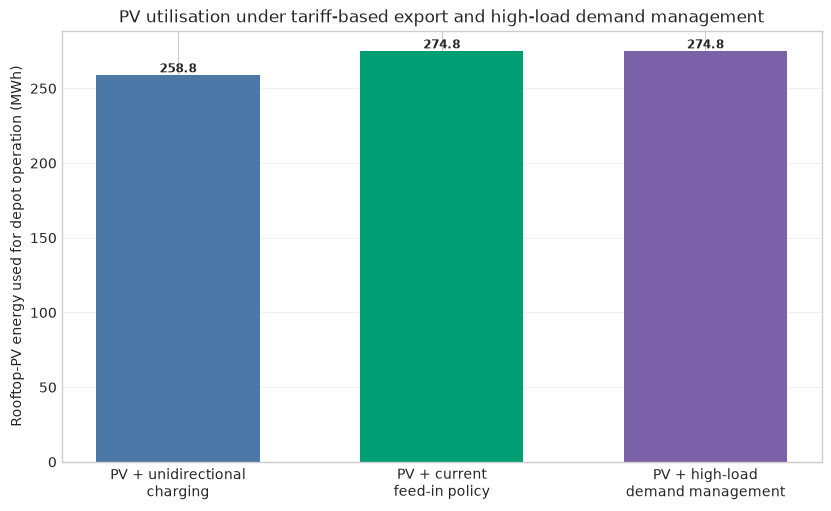

In [19]:
if not missing_pv_profile:
    pv_annual_cases = [pv_only_label, i07b_label]
    if high_load_pv_available:
        pv_annual_cases.append(i07d_label)
    pv_summary = comparison.loc[pv_annual_cases, ['pv_used_MWh', 'pv_curtailment_MWh', 'grid_export_MWh']].copy()
    labels = ['PV + unidirectional\ncharging', 'PV + current\nfeed-in policy']
    colors = ['#4C78A8', '#009E73']
    if high_load_pv_available:
        labels.append('PV + high-load\ndemand management')
        colors.append('#7B61A8')
    x = np.arange(len(pv_annual_cases))
    used = pv_summary['pv_used_MWh'].to_numpy()

    fig, use_axis = plt.subplots(figsize=(8.2, 5.0), constrained_layout=True)
    bars = use_axis.bar(x, used, color=colors, width=0.62)
    use_axis.set_xticks(x, labels)
    use_axis.set_ylabel('Rooftop-PV energy used for depot operation (MWh)')
    use_axis.set_title('PV utilisation under tariff-based export and high-load demand management')
    use_axis.grid(axis='y', alpha=0.28)
    use_axis.set_axisbelow(True)
    for bar, value in zip(bars, used):
        use_axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='semibold')
    plt.show()


findfont: Failed to find font weight semibold, now using 700.


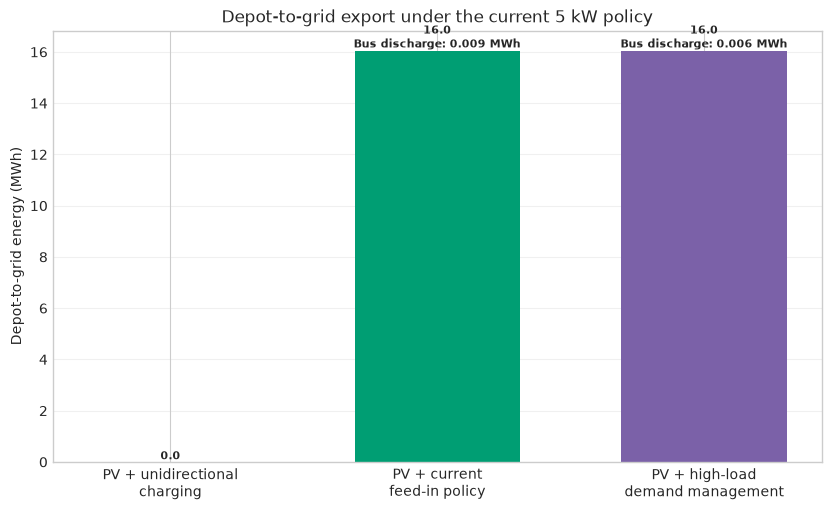

In [20]:
if not missing_pv_profile:
    exported = pv_summary['grid_export_MWh'].to_numpy()
    bus_discharge = [float(dispatch_by_case[label]['bus_discharge_MWh'].sum()) for label in pv_annual_cases]

    fig, export_axis = plt.subplots(figsize=(8.2, 5.0), constrained_layout=True)
    bars = export_axis.bar(x, exported, color=colors, width=0.62)
    export_axis.set_xticks(x, labels)
    export_axis.set_ylabel('Depot-to-grid energy (MWh)')
    export_axis.set_title('Depot-to-grid export under the current 5 kW policy')
    export_axis.grid(axis='y', alpha=0.28)
    export_axis.set_axisbelow(True)
    for bar, value, discharge in zip(bars, exported, bus_discharge):
        suffix = '' if value == 0 else f'\nBus discharge: {discharge:.3f} MWh'
        export_axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.1f}{suffix}', ha='center', va='bottom', fontsize=8.0, fontweight='semibold')
    plt.show()


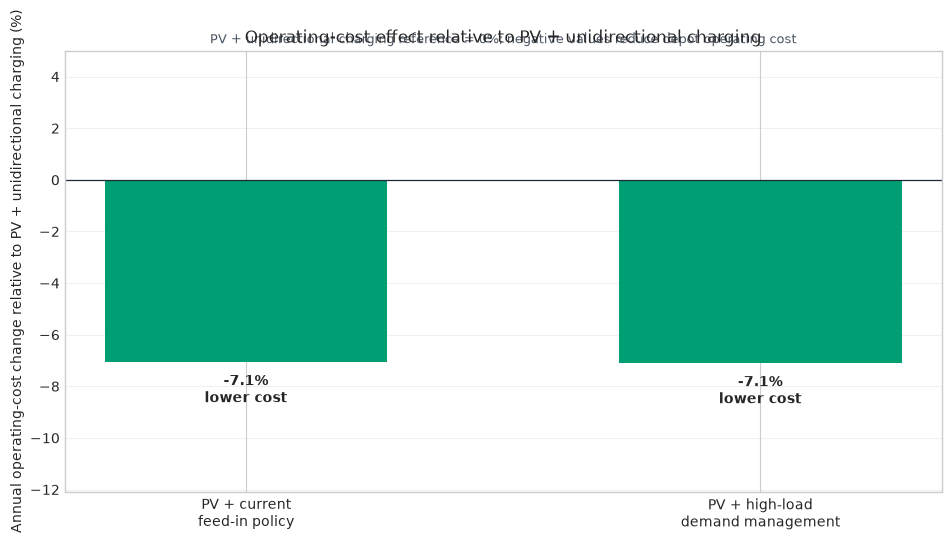

In [21]:
if not missing_pv_profile:
    pv_only_cost = comparison.loc[pv_only_label, 'total_cost_THB']
    cost_labels = [i07b_label]
    if high_load_pv_available:
        cost_labels.append(i07d_label)
    pv_cost_comparison = pd.DataFrame({
        'cost_change_pct': [
            100 * (comparison.loc[label, 'total_cost_THB'] - pv_only_cost) / pv_only_cost
            for label in cost_labels
        ]
    }, index=cost_labels)
    labels = ['PV + current\nfeed-in policy']
    if high_load_pv_available:
        labels.append('PV + high-load\ndemand management')
    values = pv_cost_comparison['cost_change_pct'].to_numpy()
    colors = ['#009E73' if value < 0 else '#D55E00' for value in values]

    fig, axis = plt.subplots(figsize=(9.4, 5.1), constrained_layout=True)
    bars = axis.bar(labels, values, color=colors, width=0.55)
    axis.axhline(0, color='#1F2937', linewidth=0.9)
    axis.set_ylabel('Annual operating-cost change relative to PV + unidirectional charging (%)')
    axis.set_title('Operating-cost effect relative to PV + unidirectional charging')
    axis.text(0.5, 1.01, 'PV + unidirectional charging reference = 0%; negative values reduce depot operating cost',
              transform=axis.transAxes, ha='center', va='bottom', fontsize=9.5, color='#4B5563')
    axis.grid(axis='y', alpha=0.28)
    axis.set_axisbelow(True)
    pad = max(abs(values).max() * 0.13, 5)
    axis.set_ylim(min(values.min() - pad, -pad), max(values.max() + pad, pad))
    for bar, value in zip(bars, values):
        direction = 'lower cost' if value < 0 else 'higher cost'
        va = 'top' if value < 0 else 'bottom'
        offset = -8 if value < 0 else 8
        axis.annotate(f'{value:+.1f}%\n{direction}',
                      (bar.get_x() + bar.get_width() / 2, value), xytext=(0, offset),
                      textcoords='offset points', ha='center', va=va, fontsize=10, fontweight='semibold')
    plt.show()


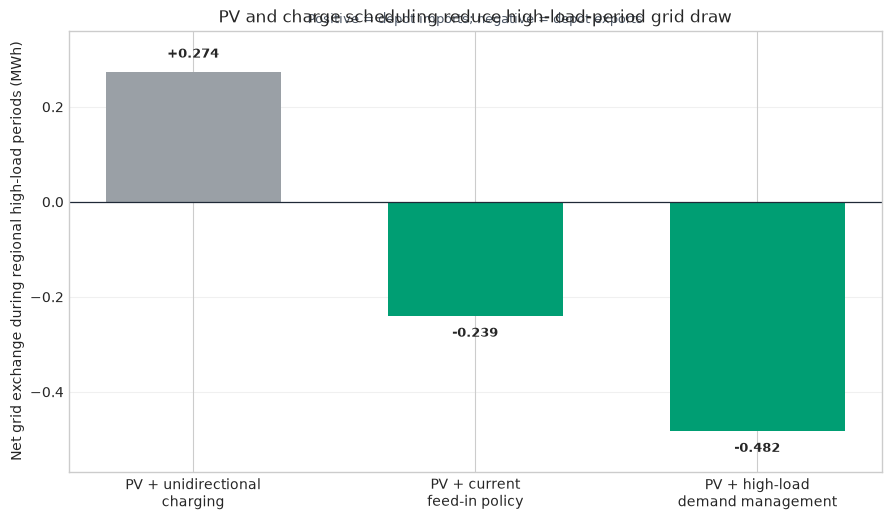

In [22]:
if not missing_pv_profile and high_load_pv_available:
    high_load_cases = [pv_only_label, i07b_label, i07d_label]
    high_load_labels = ['PV + unidirectional\ncharging', 'PV + current\nfeed-in policy', 'PV + high-load\ndemand management']
    high_load_rows = []
    for label in high_load_cases:
        dispatch = dispatch_by_case[label]
        high_load = dispatch['grid_congestion_weight'] >= dispatch['grid_stress_threshold']
        net_exchange = float((dispatch.loc[high_load, 'traction_net_grid_import_MWh']).sum())
        high_load_rows.append(net_exchange)
    high_load_colors = ['#9AA0A6' if value > 0 else '#009E73' for value in high_load_rows]

    fig, axis = plt.subplots(figsize=(8.8, 5.1), constrained_layout=True)
    bars = axis.bar(high_load_labels, high_load_rows, color=high_load_colors, width=0.62)
    axis.axhline(0, color='#1F2937', linewidth=0.9)
    axis.set_ylabel('Net grid exchange during regional high-load periods (MWh)')
    axis.set_title('PV and charge scheduling reduce high-load-period grid draw')
    axis.text(0.5, 1.01, 'Positive = depot imports; negative = depot exports',
              transform=axis.transAxes, ha='center', va='bottom', fontsize=9.5, color='#4B5563')
    axis.grid(axis='y', alpha=0.28)
    axis.set_axisbelow(True)
    span = max(max(abs(value) for value in high_load_rows) * 0.18, 0.08)
    axis.set_ylim(min(high_load_rows) - span, max(high_load_rows) + span)
    for bar, value in zip(bars, high_load_rows):
        va = 'top' if value < 0 else 'bottom'
        offset = -8 if value < 0 else 8
        axis.annotate(f'{value:+.3f}', (bar.get_x() + bar.get_width() / 2, value),
                      xytext=(0, offset), textcoords='offset points', ha='center', va=va,
                      fontsize=9.5, fontweight='semibold')
    plt.show()


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


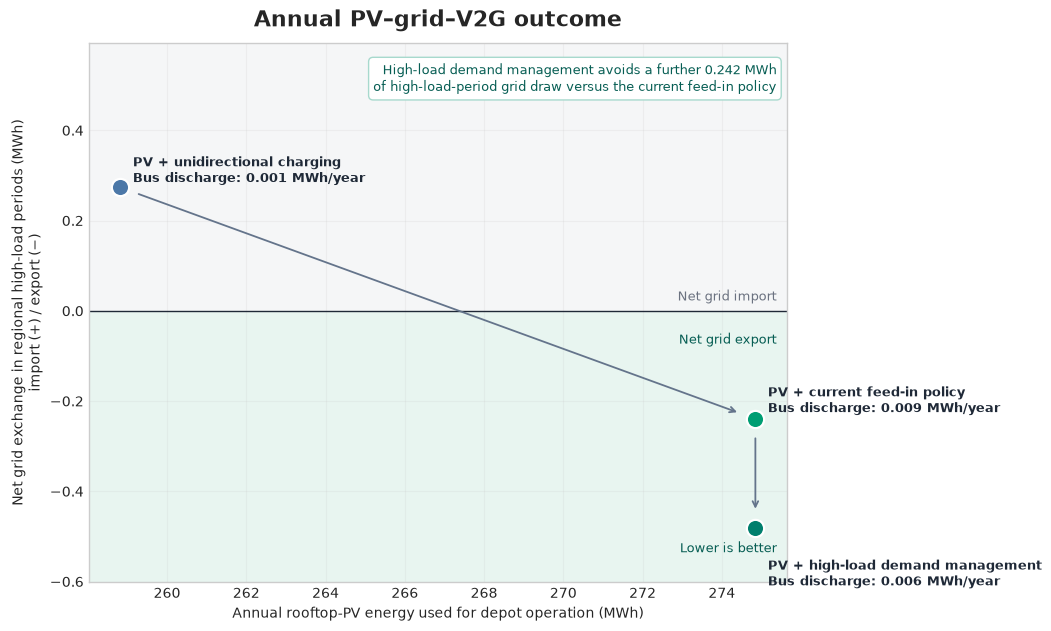

In [23]:
if not missing_pv_profile and high_load_pv_available:
    annual_map_cases = [pv_only_label, i07b_label, i07d_label]
    annual_map_labels = [
        'PV + unidirectional charging',
        'PV + current feed-in policy',
        'PV + high-load demand management',
    ]
    annual_map_colors = ['#4C78A8', '#009E73', '#007F6D']
    annual_map_rows = []
    for label in annual_map_cases:
        dispatch = dispatch_by_case[label]
        high_load = dispatch['grid_congestion_weight'] >= dispatch['grid_stress_threshold']
        annual_map_rows.append({
            'case': label,
            'pv_used_MWh': float(pv_summary.loc[label, 'pv_used_MWh']),
            'high_load_exchange_MWh': float(
                dispatch.loc[high_load, 'traction_net_grid_import_MWh'].sum()
            ),
            'bus_discharge_MWh': float(dispatch['bus_discharge_MWh'].sum()),
        })
    annual_map = pd.DataFrame(annual_map_rows, index=annual_map_labels)

    fig, axis = plt.subplots(figsize=(10.4, 6.2), constrained_layout=True)
    y_min = annual_map['high_load_exchange_MWh'].min() - 0.12
    y_max = annual_map['high_load_exchange_MWh'].max() + 0.32
    axis.axhspan(y_min, 0, color='#E8F5F0', zorder=0)
    axis.axhspan(0, y_max, color='#F5F6F7', zorder=0)
    axis.axhline(0, color='#1F2937', linewidth=1.0, zorder=1)

    for index, label in enumerate(annual_map_labels):
        row = annual_map.loc[label]
        axis.scatter(
            row['pv_used_MWh'], row['high_load_exchange_MWh'],
            s=155, color=annual_map_colors[index], edgecolor='white', linewidth=1.6,
            zorder=4,
        )

    arrow_pairs = list(zip(annual_map_labels[:-1], annual_map_labels[1:]))
    for start, end in arrow_pairs:
        start_row = annual_map.loc[start]
        end_row = annual_map.loc[end]
        axis.annotate(
            '',
            xy=(end_row['pv_used_MWh'], end_row['high_load_exchange_MWh']),
            xytext=(start_row['pv_used_MWh'], start_row['high_load_exchange_MWh']),
            arrowprops=dict(arrowstyle='->', color='#64748B', linewidth=1.3,
                            shrinkA=14, shrinkB=14),
            zorder=2,
        )

    offsets = {
        'PV + unidirectional charging': (9, 12),
        'PV + current feed-in policy': (9, 13),
        'PV + high-load demand management': (9, -33),
    }
    for label in annual_map_labels:
        row = annual_map.loc[label]
        axis.annotate(
            f'{label}\nBus discharge: {row["bus_discharge_MWh"]:.3f} MWh/year',
            (row['pv_used_MWh'], row['high_load_exchange_MWh']),
            xytext=offsets[label], textcoords='offset points', ha='left', va='center',
            fontsize=9.4, fontweight='semibold', color='#1F2937', zorder=5,
        )

    i07b_exchange = annual_map.loc['PV + current feed-in policy', 'high_load_exchange_MWh']
    i07d_exchange = annual_map.loc['PV + high-load demand management', 'high_load_exchange_MWh']
    additional_relief = i07b_exchange - i07d_exchange
    axis.text(
        0.985, 0.965,
        f'High-load demand management avoids a further {additional_relief:.3f} MWh\nof high-load-period grid draw versus the current feed-in policy',
        transform=axis.transAxes, ha='right', va='top', fontsize=9.4, color='#075E54',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#A7D9CD'),
    )
    axis.text(0.985, 0.05, 'Lower is better', transform=axis.transAxes,
              ha='right', va='bottom', fontsize=9.4, color='#075E54')
    axis.text(0.985, 0.53, 'Net grid import', transform=axis.transAxes,
              ha='right', va='center', fontsize=9, color='#6B7280')
    axis.text(0.985, 0.45, 'Net grid export', transform=axis.transAxes,
              ha='right', va='center', fontsize=9, color='#075E54')
    axis.set_title('Annual PV–grid–V2G outcome', fontsize=16, fontweight='semibold', pad=12)
    axis.set_xlabel('Annual rooftop-PV energy used for depot operation (MWh)')
    axis.set_ylabel('Net grid exchange in regional high-load periods (MWh)\nimport (+) / export (−)')
    axis.set_ylim(y_min, y_max)
    axis.grid(alpha=0.22)
    axis.set_axisbelow(True)
    plt.show()


**Interpretation.** PV creates immediate operating value. At the current limit, observed export is primarily surplus PV and charging timing rather than material bus discharge.


In [24]:
# Complete rooftop-PV family, including the higher-tariff sensitivity.
family = [
    ('PV + unidirectional charging reference', 'PV + unidirectional charging'),
    ('I07b rooftop PV operation at current export policy', 'PV + current feed-in policy'),
    ('I07c rooftop PV operation at viable export tariff', 'PV + higher feed-in tariff'),
    ('I07d PV with high-load demand management', 'PV + high-load demand management'),
]
rows = []
for scenario, name in family:
    if scenario not in dispatch_by_case:
        continue
    dispatch = dispatch_by_case[scenario]
    rows.append({
        'Scenario': name,
        'PV used (MWh/year)': float(comparison.loc[scenario, 'pv_used_MWh']),
        'PV curtailed (MWh/year)': float(comparison.loc[scenario, 'pv_curtailment_MWh']),
        'Depot-to-grid export (MWh/year)': float(dispatch['grid_export_MWh'].sum()),
        'Bus discharge (MWh/year)': float(dispatch['bus_discharge_MWh'].sum()),
        'Operating cost (THB/year)': float(comparison.loc[scenario, 'total_cost_THB']),
    })
if rows:
    pv_family = pd.DataFrame(rows).set_index('Scenario')
    display(pv_family.round(3))


,PV used (MWh/year),PV curtailed (MWh/year),Depot-to-grid export (MWh/year),Bus discharge (MWh/year),Operating cost (THB/year)
Scenario,,,,,
PV + unidirectional charging,258.823,491.432,0.000,0.001,499935.082
PV + current feed-in policy,274.847,475.408,16.028,0.009,464648.058
PV + higher feed-in tariff,274.847,475.408,23.844,2.691,446293.409
PV + high-load demand management,274.847,475.408,16.027,0.006,464445.027


## 8. Emergency V2G transfer sensitivity


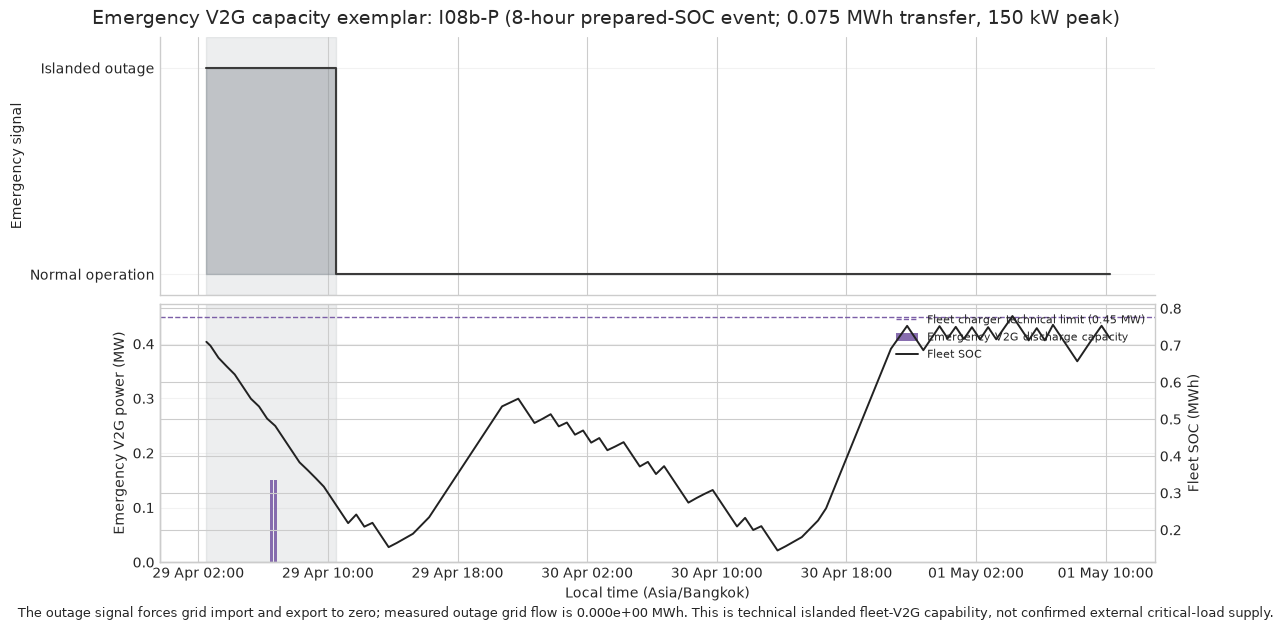

In [25]:
emergency_case_label = 'I08b-P emergency V2G 8 h prepared SOC'
if emergency_case_label not in dispatch_by_case:
    print('The emergency exemplar requires a completed I08b-P dispatch output.')
else:
    emergency_case = dispatch_by_case[emergency_case_label]
    outage = emergency_case['synthetic_outage_event'].astype(bool)
    outage_start = emergency_case.index[outage][0]
    outage_end = emergency_case.index[outage][-1] + pd.Timedelta(minutes=15)
    emergency_power_MW = emergency_case['bus_discharge_MWh'] / 0.25
    peak_emergency_kW = float(emergency_power_MW.loc[outage].max() * 1000.0)
    transfer_MWh = float(emergency_case.loc[outage, 'bus_discharge_MWh'].sum())
    outage_grid_flow_MWh = float((emergency_case.loc[outage, 'grid_import_MWh'] + emergency_case.loc[outage, 'grid_export_MWh']).sum())

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)
    axes[0].step(emergency_case.index, outage.astype(int), where='post', color='#3b3b3b', linewidth=1.5)
    axes[0].fill_between(emergency_case.index, 0, outage.astype(int), step='post', color='#6c757d', alpha=0.35)
    axes[0].set_yticks([0, 1], labels=['Normal operation', 'Islanded outage'])
    axes[0].set_ylim(-0.1, 1.15)
    axes[0].set_ylabel('Emergency signal')

    axes[1].bar(emergency_case.index[outage], emergency_power_MW.loc[outage], width=pd.Timedelta(minutes=12), color='#7b5ea7', alpha=0.9, label='Emergency V2G discharge capacity')
    axes[1].axhline(0.45, color='#7b5ea7', linestyle='--', linewidth=1.0, label='Fleet charger technical limit (0.45 MW)')
    axes[1].set_ylabel('Emergency V2G power (MW)')
    axes[1].set_xlabel('Local time (Asia/Bangkok)')
    soc_axis = axes[1].twinx()
    soc_axis.plot(emergency_case.index, emergency_case['bus_soc_MWh'], color='#222222', linewidth=1.4, label='Fleet SOC')
    soc_axis.set_ylabel('Fleet SOC (MWh)')
    handles, labels = axes[1].get_legend_handles_labels()
    soc_handles, soc_labels = soc_axis.get_legend_handles_labels()
    axes[1].legend(handles + soc_handles, labels + soc_labels, loc='upper right', fontsize=8, frameon=False)

    for axis in axes:
        axis.axvspan(outage_start, outage_end, color='#6c757d', alpha=0.12, zorder=0)
        axis.grid(axis='y', alpha=0.25)
        axis.set_axisbelow(True)
        axis.spines[['top', 'right']].set_visible(False)
    axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=8))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
    fig.suptitle(f'Emergency V2G capacity exemplar: I08b-P (8-hour prepared-SOC event; {transfer_MWh:.3f} MWh transfer, {peak_emergency_kW:.0f} kW peak)', fontsize=14)
    fig.text(0.01, -0.02, f'The outage signal forces grid import and export to zero; measured outage grid flow is {outage_grid_flow_MWh:.3e} MWh. This is technical islanded fleet-V2G capability, not confirmed external critical-load supply.', fontsize=9)
    plt.show()


### Emergency capacity and recovery-cost summary

This resilience-envelope plot combines the technical and operating dimensions of I08. The vertical axis is the maximum emergency V2G power available during the outage, the horizontal axis is the outage duration, bubble area is emergency energy transferred, and colour is the recovery-energy cost gap per transferred kWh relative to matched V1G operation. Prepared-SOC cases assume the event is known in advance; inherited-SOC cases represent normal-operation readiness. I08 remains a technical islanded fleet-to-fleet transfer sensitivity, not confirmed external critical-load supply.


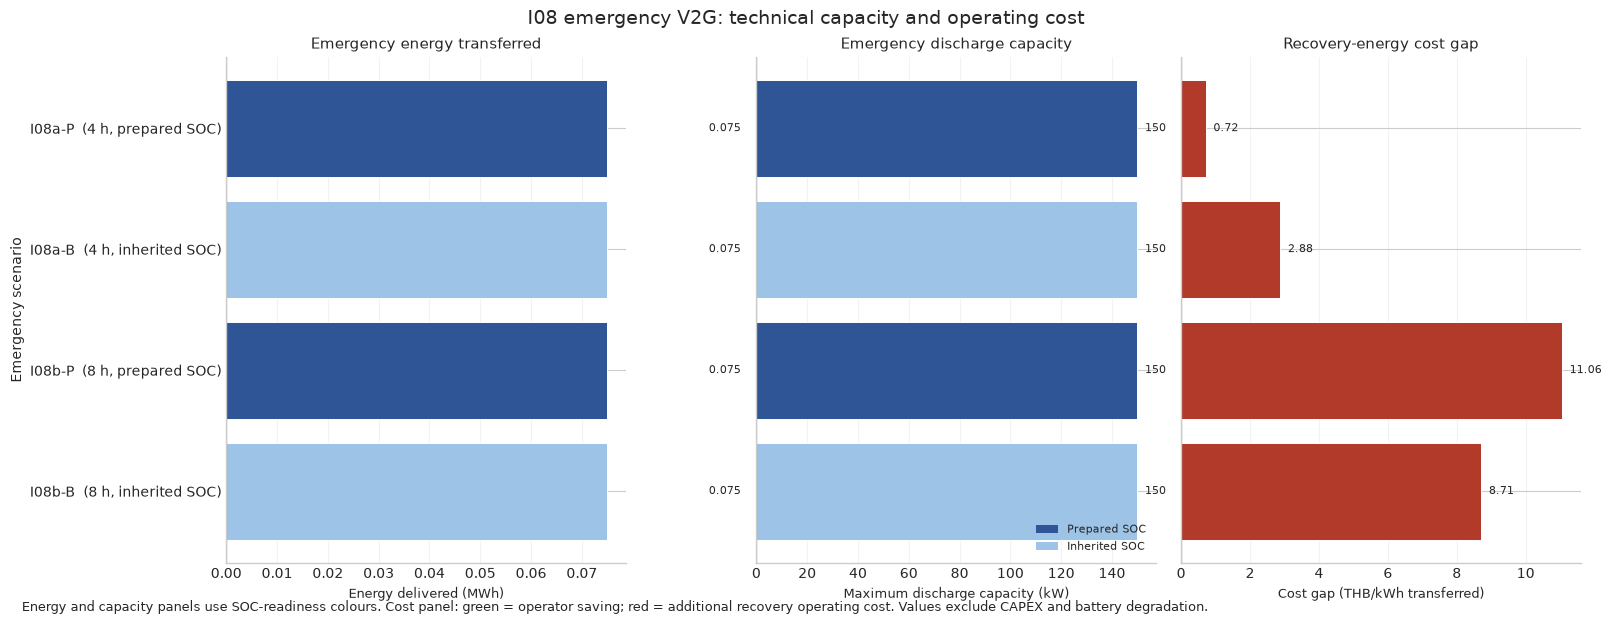

In [26]:
# Build the shared service-cost table here because the I08 figure appears before
# the detailed cost-gap section later in the notebook.
service_cost_gap = build_service_cost_gap(comparison, dispatch_by_case)

i08_gap = service_cost_gap[service_cost_gap['time_basis'] == 'event'].copy() if not service_cost_gap.empty else pd.DataFrame()
i08_rows = []
for scenario, row in i08_gap.iterrows():
    dispatch = dispatch_by_case.get(scenario)
    if dispatch is None:
        continue
    outage = dispatch.get('synthetic_outage_event', pd.Series(False, index=dispatch.index)).astype(bool)
    i08_rows.append({
        'scenario': scenario,
        'duration_h': float(outage.sum() * 0.25),
        'peak_power_kW': float(row['peak_service_kW']),
        'transfer_MWh': float(row['service_energy_MWh']),
        'cost_gap_per_kWh': float(row['cost_gap_THB_per_service_kWh']),
        'cost_gap_THB': float(row['cost_gap_THB']),
    })
i08_plot = pd.DataFrame(i08_rows).dropna()
if i08_plot.empty:
    print('No completed I08 results are available for the resilience-envelope plot.')
else:
    preferred_order = ['I08a-P emergency V2G 4 h prepared SOC', 'I08a-B emergency V2G 4 h inherited SOC', 'I08b-P emergency V2G 8 h prepared SOC', 'I08b-B emergency V2G 8 h inherited SOC']
    i08_plot['order'] = i08_plot['scenario'].map({name: position for position, name in enumerate(preferred_order)})
    i08_plot = i08_plot.sort_values('order')
    label_map = {
        'I08a-P emergency V2G 4 h prepared SOC': 'I08a-P  (4 h, prepared SOC)',
        'I08a-B emergency V2G 4 h inherited SOC': 'I08a-B  (4 h, inherited SOC)',
        'I08b-P emergency V2G 8 h prepared SOC': 'I08b-P  (8 h, prepared SOC)',
        'I08b-B emergency V2G 8 h inherited SOC': 'I08b-B  (8 h, inherited SOC)',
    }
    i08_plot['label'] = i08_plot['scenario'].map(label_map)
    labels = i08_plot['label'].tolist()[::-1]
    prepared_color = '#2f5597'
    inherited_color = '#9dc3e6'
    soc_colors = [prepared_color if '-P ' in name else inherited_color for name in i08_plot['scenario']][::-1]
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True, constrained_layout=True)
    panels = [
        ('transfer_MWh', 'Emergency energy transferred', 'Energy delivered (MWh)', '{:.3f}'),
        ('peak_power_kW', 'Emergency discharge capacity', 'Maximum discharge capacity (kW)', '{:.0f}'),
        ('cost_gap_per_kWh', 'Recovery-energy cost gap', 'Cost gap (THB/kWh transferred)', '{:.2f}'),
    ]
    for panel_number, (column, title, xlabel, number_format) in enumerate(panels):
        axis = axes[panel_number]
        values = i08_plot[column].to_numpy(dtype=float)[::-1]
        colors = soc_colors if column != 'cost_gap_per_kWh' else ['#00856a' if value < 0 else '#b23a2b' for value in values]
        bars = axis.barh(labels, values, color=colors, edgecolor='white', linewidth=0.7)
        axis.axvline(0, color='#333333', linewidth=0.8)
        span = max(float(np.max(np.abs(values))), 1.0)
        for bar, value in zip(bars, values):
            offset = 0.02 * span if value >= 0 else -0.02 * span
            axis.text(value + offset, bar.get_y() + bar.get_height() / 2, number_format.format(value), va='center', ha='left' if value >= 0 else 'right', fontsize=8)
        axis.set_title(title, fontsize=11)
        axis.set_xlabel(xlabel, fontsize=9)
        axis.grid(axis='x', alpha=0.25)
        axis.set_axisbelow(True)
        axis.spines[['top', 'right']].set_visible(False)
    axes[0].set_ylabel('Emergency scenario', fontsize=10)
    from matplotlib.patches import Patch
    axes[1].legend(handles=[Patch(facecolor=prepared_color, label='Prepared SOC'), Patch(facecolor=inherited_color, label='Inherited SOC')], loc='lower right', fontsize=8, frameon=False)
    fig.suptitle('I08 emergency V2G: technical capacity and operating cost', fontsize=14)
    fig.text(0.01, -0.01, 'Energy and capacity panels use SOC-readiness colours. Cost panel: green = operator saving; red = additional recovery operating cost. Values exclude CAPEX and battery degradation.', fontsize=9)
    plt.show()


## 9. Cross-case annual comparison


### Cross-case grid and renewable indicators

The grid figure shows each case's actual signed net grid exchange during regional high-load periods, sorted from export to import. Negative values mean net export to the grid; positive values mean net import from the grid. Green indicates export, grey indicates zero exchange, and red indicates import. A separate figure shows renewable-equivalent charging absorption for the same completed cases. Diesel is excluded because it has no grid connection in the study boundary.


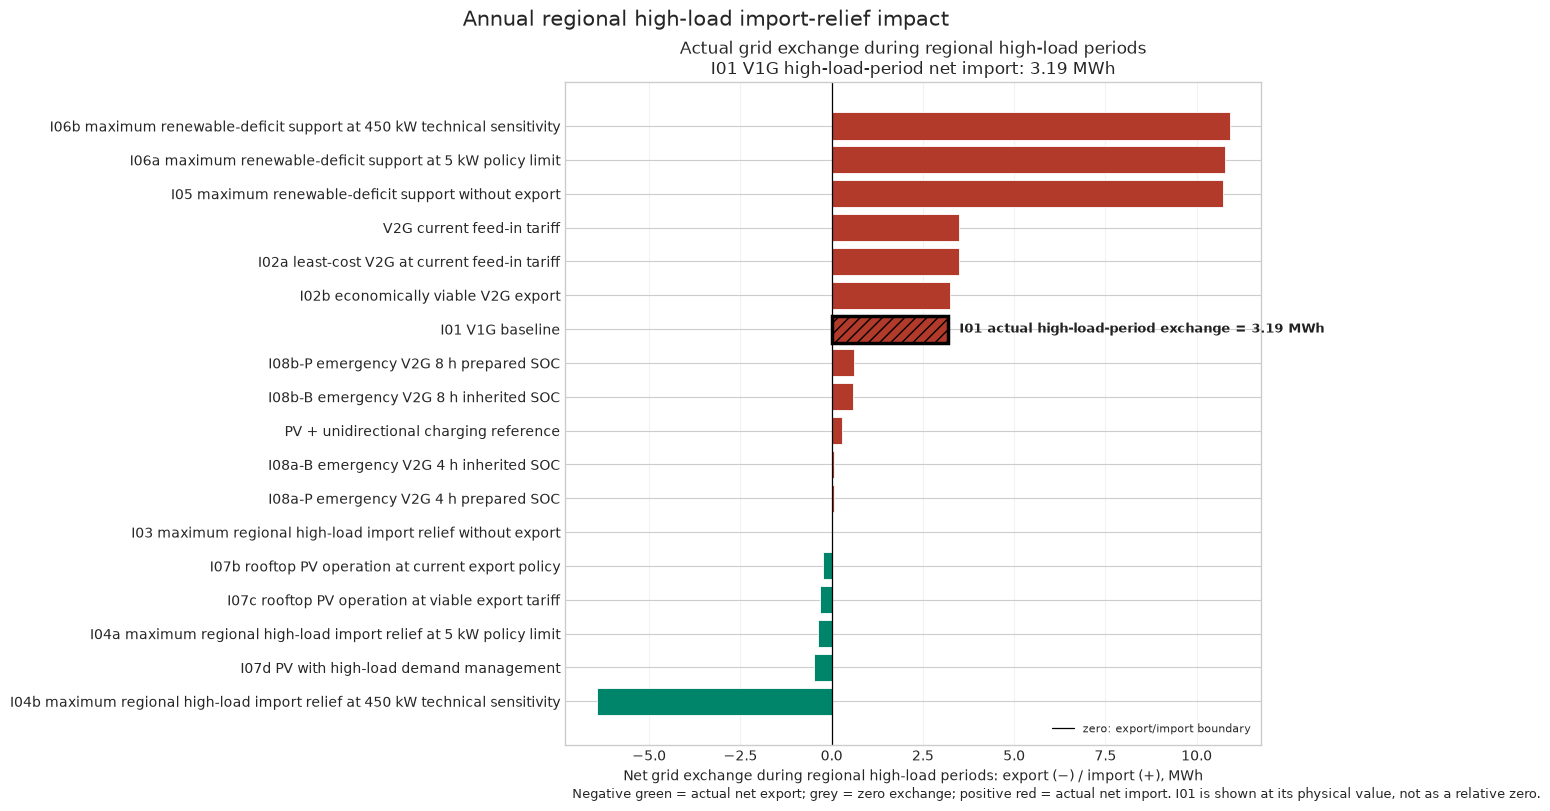

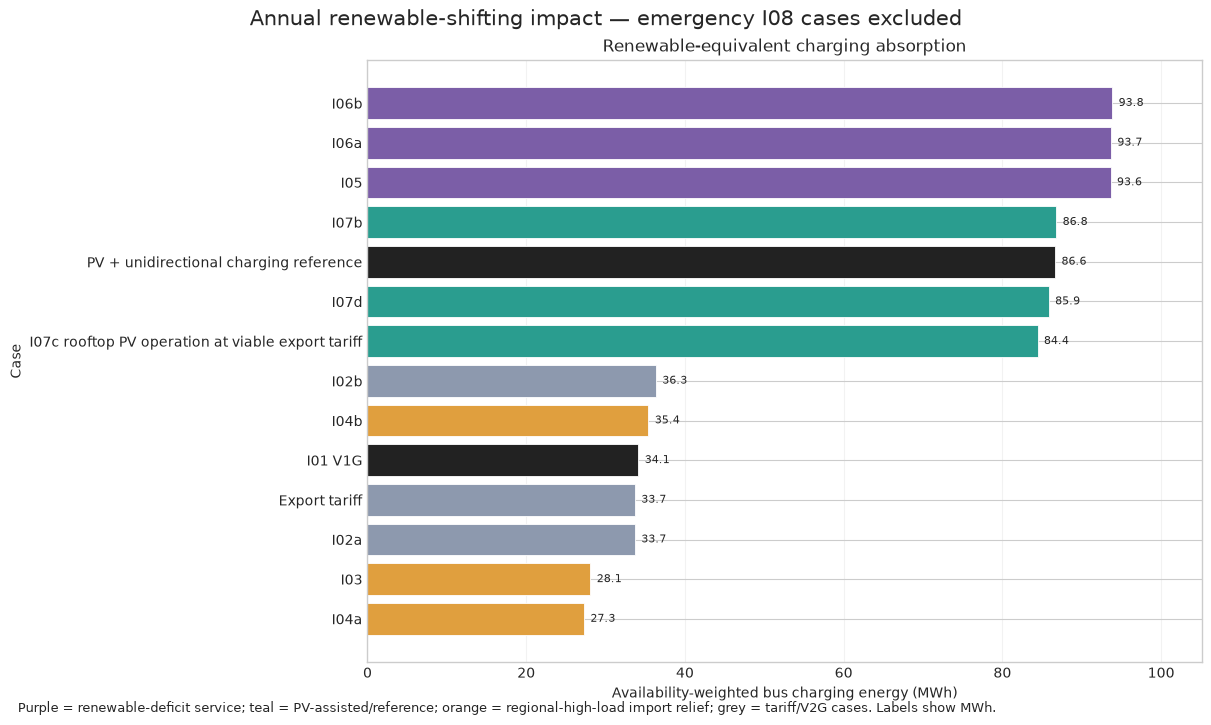

In [27]:
# Regional high-load import-relief indicators are shown as absolute grid exchange during high-load periods.
# I01 is included as the ordinary V1G reference bar.
impact = comparison.drop(index='Diesel benchmark', errors='ignore').copy()
impact = impact.loc[impact.index.intersection(dispatch_by_case)]

figure, axis = plt.subplots(figsize=(14, 8), constrained_layout=True)

stress_rows = []
for label, dispatch in dispatch_by_case.items():
    stress = dispatch['grid_congestion_weight'] >= dispatch['grid_stress_threshold']
    stress_rows.append({
        'scenario': 'I01 V1G baseline' if label == 'V1G baseline' else label,
        'net_grid_exchange_MWh': float(dispatch.loc[stress, 'traction_net_grid_import_MWh'].sum()),
        'bus_discharge_MWh': float(dispatch.loc[stress, 'bus_discharge_MWh'].sum()),
    })
stress_summary = pd.DataFrame(stress_rows).set_index('scenario')
i01_stress_import = float(stress_summary.loc['I01 V1G baseline', 'net_grid_exchange_MWh']) if 'I01 V1G baseline' in stress_summary.index else float('nan')
stress_summary = stress_summary.sort_values('net_grid_exchange_MWh')
stress_impact = stress_summary['net_grid_exchange_MWh']
tolerance = 1e-6
grid_colors = []
for value in stress_impact:
    if value < -tolerance:
        grid_colors.append('#00856a')  # net export
    elif abs(value) <= tolerance:
        grid_colors.append('#7f8c8d')  # zero exchange
    else:
        grid_colors.append('#b23a2b')  # net import
bars = axis.barh(stress_impact.index, stress_impact.values, color=grid_colors, edgecolor='white', linewidth=0.6)
if 'I01 V1G baseline' in stress_impact.index:
    i01_position = list(stress_impact.index).index('I01 V1G baseline')
    bars[i01_position].set_edgecolor('black')
    bars[i01_position].set_linewidth(2.5)
    bars[i01_position].set_hatch('///')
    axis.annotate(f'I01 actual high-load-period exchange = {i01_stress_import:.2f} MWh', xy=(i01_stress_import, i01_position), xytext=(8, 0), textcoords='offset points', va='center', fontsize=9, fontweight='bold', color='#222222')
axis.axvline(0.0, color='black', linewidth=0.9, label='zero: export/import boundary')
axis.set_title(f'Actual grid exchange during regional high-load periods\nI01 V1G high-load-period net import: {i01_stress_import:.2f} MWh')
axis.set_xlabel('Net grid exchange during regional high-load periods: export (−) / import (+), MWh')
axis.legend(fontsize=8, loc='lower right')
axis.text(0.01, -0.08, 'Negative green = actual net export; grey = zero exchange; positive red = actual net import. I01 is shown at its physical value, not as a relative zero.', transform=axis.transAxes, fontsize=9)
axis.grid(axis='x', alpha=0.25)
axis.set_axisbelow(True)

figure.suptitle('Annual regional high-load import-relief impact', fontsize=15)
plt.show()

# Emergency cases are resilience tests, not renewable-shifting cases, so they are not plotted here.
renewable_impact = impact.loc[~impact.index.str.startswith('I08'), 'renewable_absorbed_MWh'].fillna(0.0)
renewable_impact = renewable_impact.sort_values(ascending=True)
renewable_short_labels = {
    'V1G baseline': 'I01 V1G',
    'PV-only operating reference': 'PV-only',
    'V2G current feed-in tariff': 'Export tariff',
    'I02a least-cost V2G at current feed-in tariff': 'I02a',
    'I02b economically viable V2G export': 'I02b',
    'I03 maximum regional high-load import relief without export': 'I03',
    'I04a maximum regional high-load import relief at 5 kW policy limit': 'I04a',
    'I04b maximum regional high-load import relief at 450 kW technical sensitivity': 'I04b',
    'I05 maximum renewable-deficit support without export': 'I05',
    'I06a maximum renewable-deficit support at 5 kW policy limit': 'I06a',
    'I06b maximum renewable-deficit support at 450 kW technical sensitivity': 'I06b',
    'I07b rooftop PV operation at current export policy': 'I07b',
    'I07d PV with high-load demand management': 'I07d',
}
renewable_labels = [renewable_short_labels.get(name, name) for name in renewable_impact.index]
renewable_colors = []
for name in renewable_impact.index:
    if name.startswith('I05') or name.startswith('I06'):
        renewable_colors.append('#7b5ea7')
    elif name.startswith('I07') or name == 'PV-only operating reference':
        renewable_colors.append('#2a9d8f')
    elif name.startswith('I03') or name.startswith('I04'):
        renewable_colors.append('#e09f3e')
    elif name.startswith('I02') or name == 'V2G current feed-in tariff':
        renewable_colors.append('#8d99ae')
    else:
        renewable_colors.append('#222222')
renewable_figure, renewable_axis = plt.subplots(figsize=(12, 7), constrained_layout=True)
renewable_bars = renewable_axis.barh(renewable_labels, renewable_impact.values, color=renewable_colors, edgecolor='white', linewidth=0.6)
for bar, value in zip(renewable_bars, renewable_impact.values):
    renewable_axis.text(value + 0.8, bar.get_y() + bar.get_height() / 2, f'{value:.1f}', va='center', fontsize=8)
renewable_axis.set_title('Renewable-equivalent charging absorption')
renewable_axis.set_xlabel('Availability-weighted bus charging energy (MWh)')
renewable_axis.set_ylabel('Case')
renewable_axis.set_xlim(0, max(renewable_impact.max() * 1.12, 1.0))
renewable_axis.grid(axis='x', alpha=0.25)
renewable_axis.set_axisbelow(True)
renewable_figure.suptitle('Annual renewable-shifting impact — emergency I08 cases excluded', fontsize=15)
renewable_figure.text(0.01, -0.01, 'Purple = renewable-deficit service; teal = PV-assisted/reference; orange = regional-high-load import relief; grey = tariff/V2G cases. Labels show MWh.', fontsize=9)
plt.show()


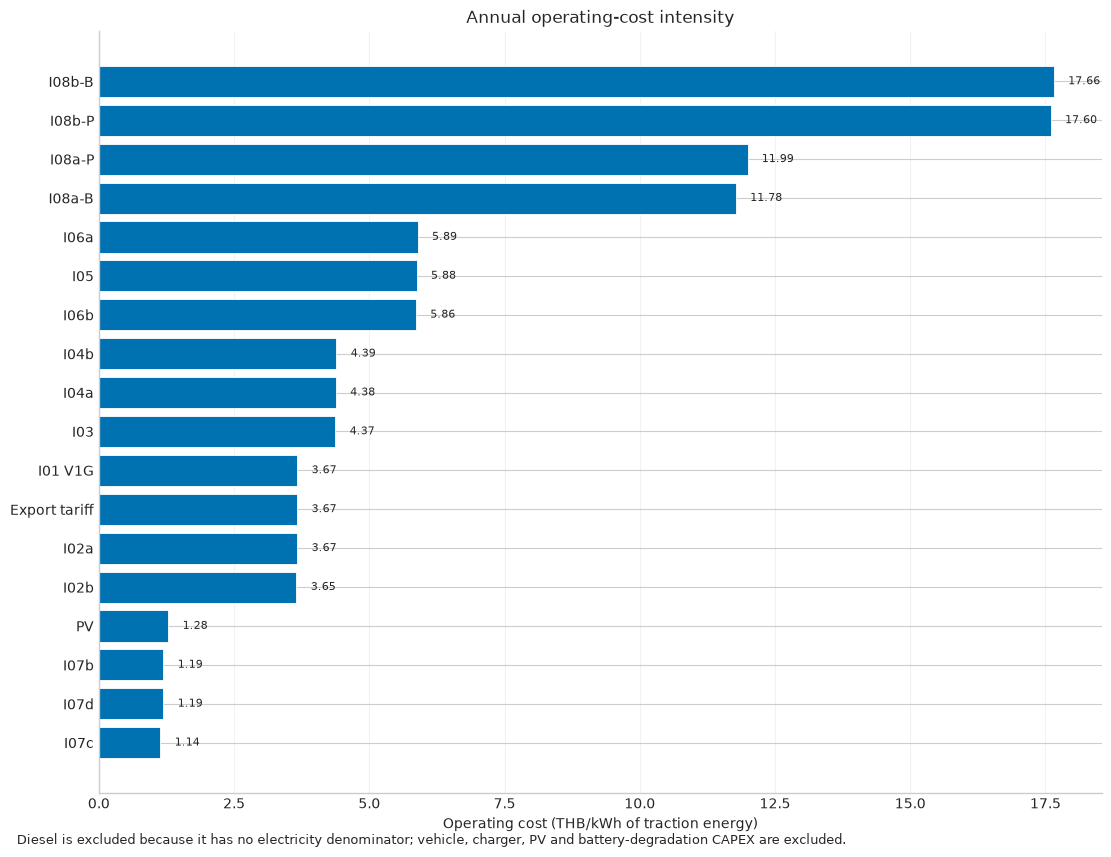

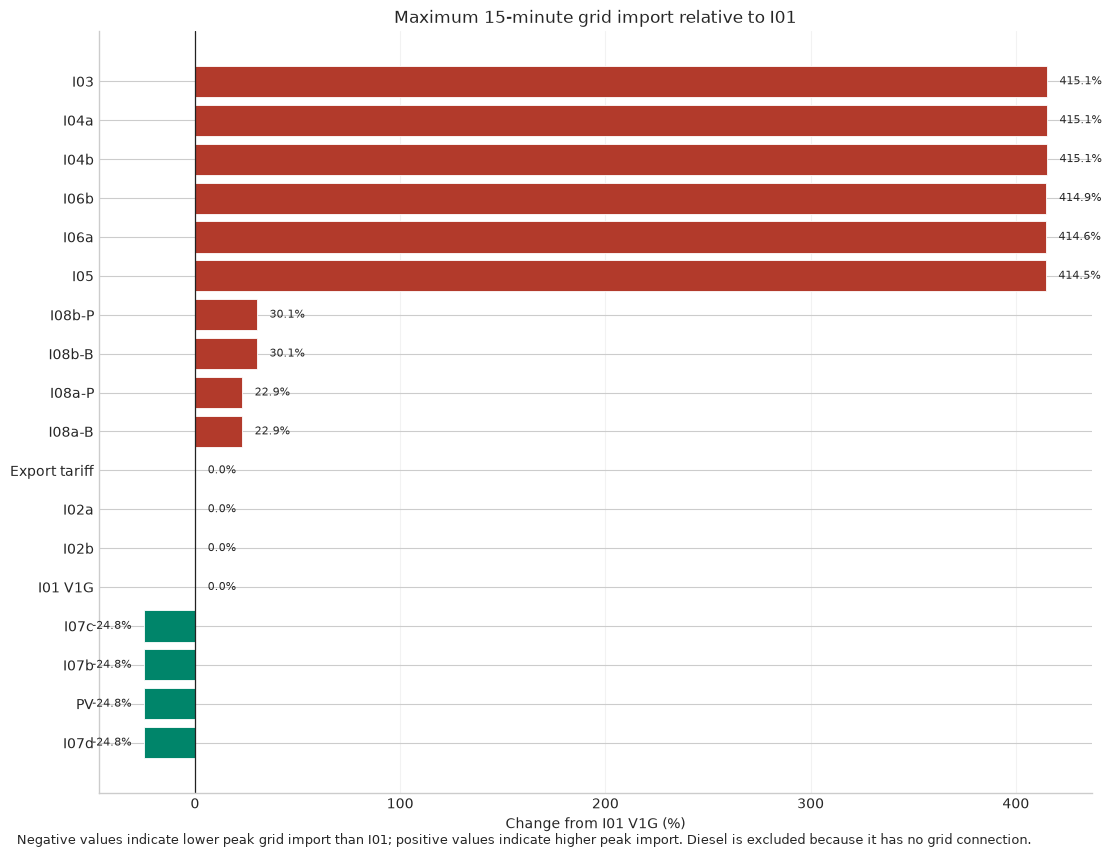

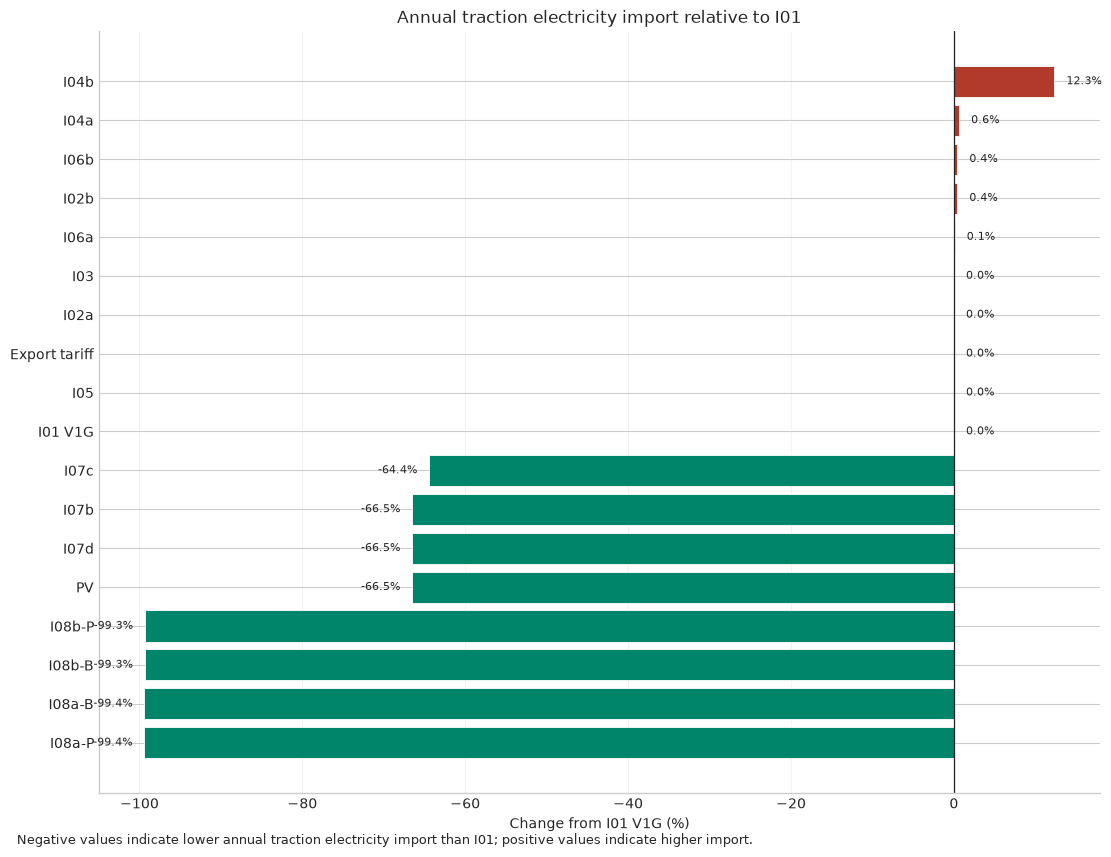

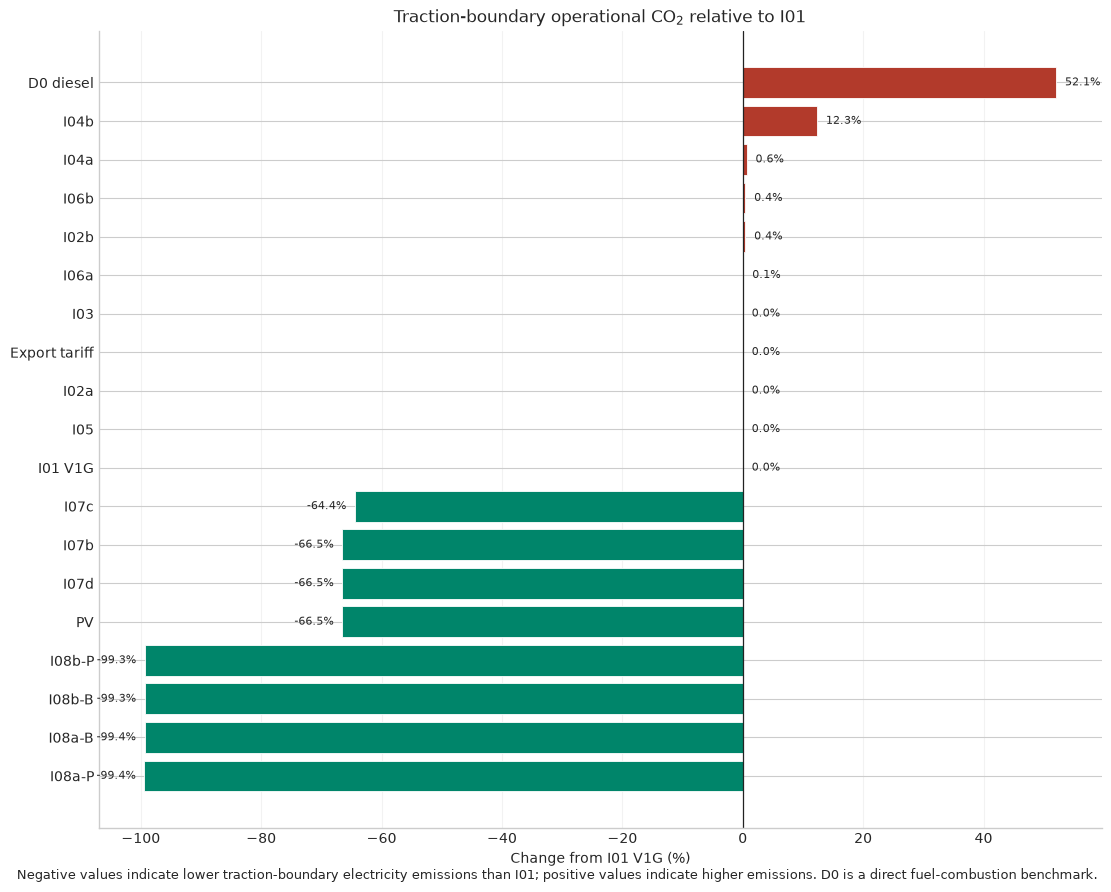

In [28]:
def concise_case_label(name):
    if name == 'Diesel benchmark':
        return 'D0 diesel'
    if name == 'V1G baseline':
        return 'I01 V1G'
    if name == 'PV-only operating reference':
        return 'PV-only'
    if name == 'V2G current feed-in tariff':
        return 'Export tariff'
    return name.split()[0]

electric_plot_data = comparison.loc[comparison.index.intersection(dispatch_by_case)].copy()
electric_charge_MWh = pd.Series({label: float(dispatch['bus_charge_MWh'].sum()) for label, dispatch in dispatch_by_case.items()})
electric_plot_data['cost_THB_per_kWh_traction'] = electric_plot_data['total_cost_THB'] / electric_charge_MWh.reindex(electric_plot_data.index) / 1000.0

def academic_bar(values, title, xlabel, colors, relative=False, note=None):
    values = values.dropna().sort_values()
    labels = [concise_case_label(name) for name in values.index]
    fig, axis = plt.subplots(figsize=(11, max(5.5, 0.35 * len(values) + 2)), constrained_layout=True)
    bars = axis.barh(labels, values.values, color=colors.reindex(values.index).values, edgecolor='white', linewidth=0.6)
    if relative:
        axis.axvline(0, color='#222222', linewidth=0.9)
    span = max(float(np.max(np.abs(values.values))), 1.0)
    for bar, value in zip(bars, values.values):
        offset = 0.015 * span if value >= 0 else -0.015 * span
        number = f'{value:.1f}%' if relative else f'{value:.2f}'
        axis.text(value + offset, bar.get_y() + bar.get_height() / 2, number, va='center', ha='left' if value >= 0 else 'right', fontsize=8)
    axis.set_title(title, fontsize=12)
    axis.set_xlabel(xlabel, fontsize=10)
    axis.grid(axis='x', alpha=0.25)
    axis.set_axisbelow(True)
    axis.spines[['top', 'right']].set_visible(False)
    if note:
        fig.text(0.01, -0.01, note, fontsize=9)
    plt.show()

# 1. Cost intensity is reported in THB per kWh of traction energy delivered to the buses.
cost_colors = pd.Series(COLORS['blue'], index=electric_plot_data.index)
academic_bar(electric_plot_data['cost_THB_per_kWh_traction'], 'Annual operating-cost intensity', 'Operating cost (THB/kWh of traction energy)', cost_colors, note='Diesel is excluded because it has no electricity denominator; vehicle, charger, PV and battery-degradation CAPEX are excluded.')

v1g = comparison.loc['V1G baseline']

# 2. Maximum grid import relative to I01. Diesel is excluded because it is not grid-connected.
peak_import_relative = 100.0 * (electric_plot_data['peak_grid_import_MW'] - v1g['peak_grid_import_MW']) / v1g['peak_grid_import_MW']
peak_import_colors = peak_import_relative.map(lambda value: '#00856a' if value < 0 else '#b23a2b')
academic_bar(peak_import_relative, 'Maximum 15-minute grid import relative to I01', 'Change from I01 V1G (%)', peak_import_colors, relative=True, note='Negative values indicate lower peak grid import than I01; positive values indicate higher peak import. Diesel is excluded because it has no grid connection.')

# 3. Annual traction electricity import relative to I01.
annual_import_relative = 100.0 * (electric_plot_data['grid_import_MWh'] - v1g['grid_import_MWh']) / v1g['grid_import_MWh']
annual_import_colors = annual_import_relative.map(lambda value: '#00856a' if value < 0 else '#b23a2b')
academic_bar(annual_import_relative, 'Annual traction electricity import relative to I01', 'Change from I01 V1G (%)', annual_import_colors, relative=True, note='Negative values indicate lower annual traction electricity import than I01; positive values indicate higher import.')

# 4. Traction-boundary operational CO2 relative to I01; D0 is retained as the diesel benchmark.
co2_relative = 100.0 * (comparison['operational_CO2_kg'] - v1g['operational_CO2_kg']) / v1g['operational_CO2_kg']
co2_colors = co2_relative.map(lambda value: '#00856a' if value < 0 else '#b23a2b')
academic_bar(co2_relative, 'Traction-boundary operational CO$_2$ relative to I01', 'Change from I01 V1G (%)', co2_colors, relative=True, note='Negative values indicate lower traction-boundary electricity emissions than I01; positive values indicate higher emissions. D0 is a direct fuel-combustion benchmark.')


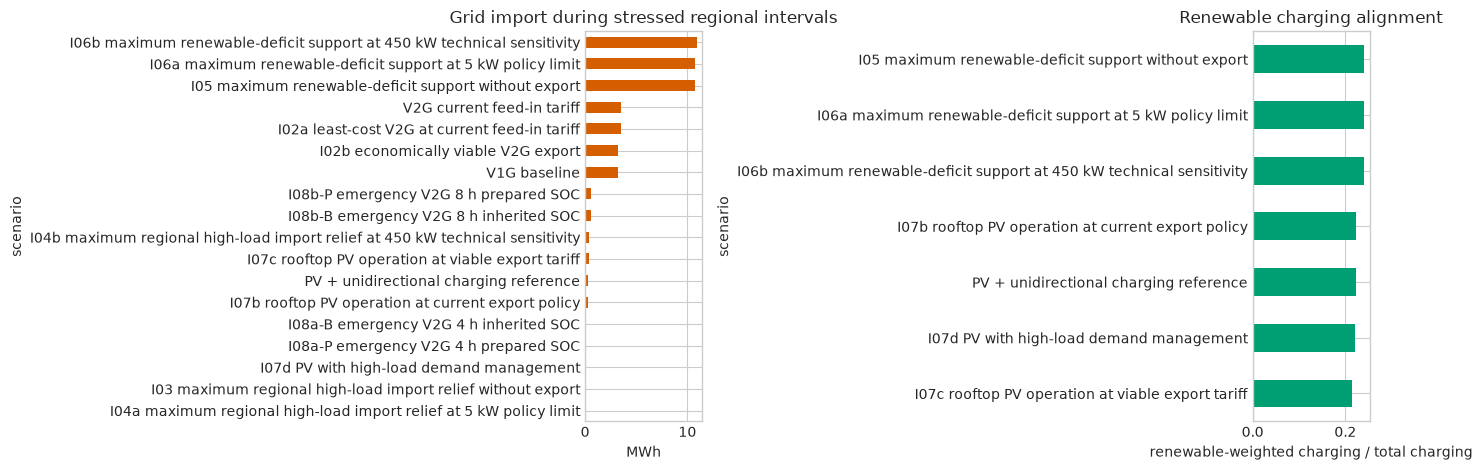

In [29]:
electric_only = comparison.drop(index='Diesel benchmark', errors='ignore')
figure, axes = plt.subplots(1, 2, figsize=(14, 4.8))
electric_only['grid_import_during_stress_MWh'].sort_values().plot.barh(ax=axes[0], color=COLORS['orange'])
axes[0].set_title('Grid import during stressed regional intervals')
axes[0].set_xlabel('MWh')
alignment = electric_only['renewable_alignment_score'].dropna().sort_values()
if not alignment.empty:
    alignment.plot.barh(ax=axes[1], color=COLORS['green'])
    axes[1].set_xlabel('renewable-weighted charging / total charging')
else:
    axes[1].text(0.5, 0.5, 'No renewable KPI in available outputs', ha='center', va='center')
axes[1].set_title('Renewable charging alignment')
figure.tight_layout()
plt.show()


## 10. Completed-case results, service cost gaps, and beneficiaries


### Cost gap for non-revenue services

The cost gap is the operator's operating-cost difference from the relevant least-cost mobility baseline. It is a compensation indicator, not a market-clearing price, capital-cost estimate, or Thai tariff recommendation. Annual cases report THB/kWh of modelled service and THB/kW-year; emergency cases report THB/kWh of emergency transfer and THB/kW-event. A missing unit value means that no measurable externally delivered service exists under the zero non-traction-load boundary. For I05/I06, the external-service denominator is a narrow renewable-availability proxy and is therefore retained only as a technical service indicator; the common-mobility operating-cost comparison is reported separately below.


,service_type,comparison_basis,time_basis,cost_gap_THB,service_energy_MWh,peak_service_kW,cost_gap_THB_per_service_kWh,cost_gap_THB_per_kW_year,cost_gap_THB_per_kW_event,potential_monthly_demand_charge_exposure_THB,unit_cost_status,islanding_check
scenario,,,,,,,,,,,,
I03 maximum regional high-load import relief without export,regional high-load import relief,V1G baseline,annual,274109.463,3.194,87.368,85.822,3137.397,NaN,NaN,compensation gap,NaN
I04a maximum regional high-load import relief at 5 kW policy limit,regional high-load import relief,V1G baseline,annual,290474.085,3.578,92.368,81.190,3144.734,NaN,NaN,compensation gap,NaN
I04b maximum regional high-load import relief at 450 kW technical sensitivity,regional high-load import relief,V1G baseline,annual,493224.936,9.626,387.368,51.238,1273.271,NaN,NaN,compensation gap,NaN
I05 maximum renewable-deficit support without export,renewable-equivalent proxy service,V1G baseline,annual,858794.242,0.000,87.368,NaN,NaN,NaN,NaN,compensation gap,NaN
I06a maximum renewable-deficit support at 5 kW policy limit,renewable-equivalent proxy service,V1G baseline,annual,868405.891,0.310,92.369,2798.459,9401.525,NaN,NaN,compensation gap,NaN
I06b maximum renewable-deficit support at 450 kW technical sensitivity,renewable-equivalent proxy service,V1G baseline,annual,863240.541,1.409,330.443,612.787,2612.375,NaN,NaN,compensation gap,NaN
I07b rooftop PV operation at current export policy,rooftop-PV export,PV + unidirectional charging reference,annual,-35287.023,16.028,5.000,-2.202,-7057.405,NaN,NaN,operator saving,NaN
I07c rooftop PV operation at viable export tariff,rooftop-PV export,PV + unidirectional charging reference,annual,-53641.673,23.844,5.000,-2.250,-10728.335,NaN,NaN,operator saving,NaN
I07d PV with high-load demand management,PV high-load demand management,PV + unidirectional charging reference,annual,-35490.054,0.755,65.683,-46.982,-540.327,NaN,NaN,operator saving,NaN


I08 demand-charge values are potential monthly exposure only: whether a charge is actually incurred depends on the unmodelled monthly maximum outside the event window.
Renewable-responsive operator cost, using the common annual bus-traction energy denominator:


,annual_bus_traction_energy_MWh,total_operating_cost_THB,operating_cost_THB_per_traction_kWh,additional_cost_vs_V1G_THB_per_traction_kWh
scenario,,,,
V1G baseline,369.66,1427478.195,3.862,0.000
I05 maximum renewable-deficit support without export,369.66,2286272.436,6.185,2.323
I06a maximum renewable-deficit support at 5 kW policy limit,369.66,2295884.086,6.211,2.349
I06b maximum renewable-deficit support at 450 kW technical sensitivity,369.66,2290718.736,6.197,2.335


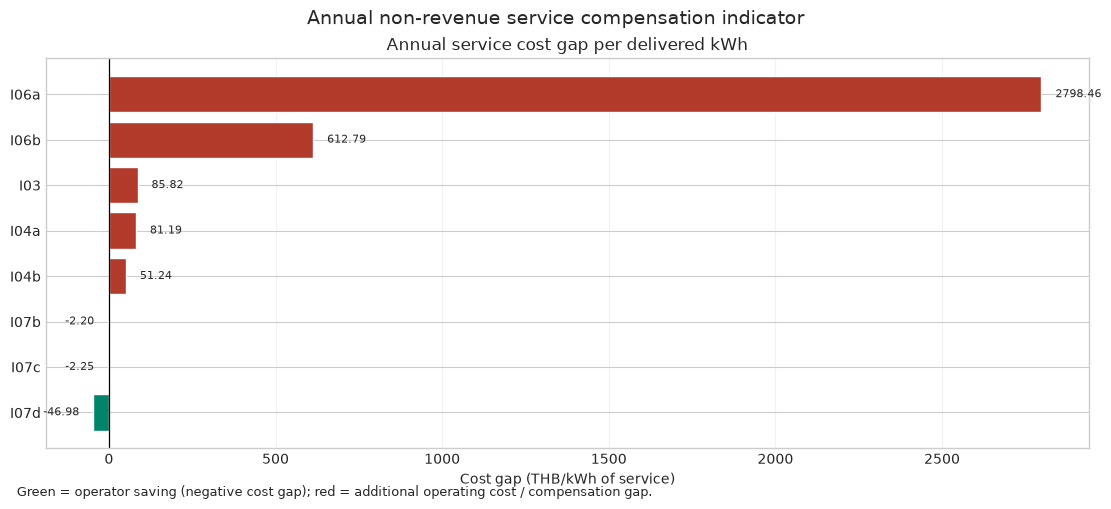

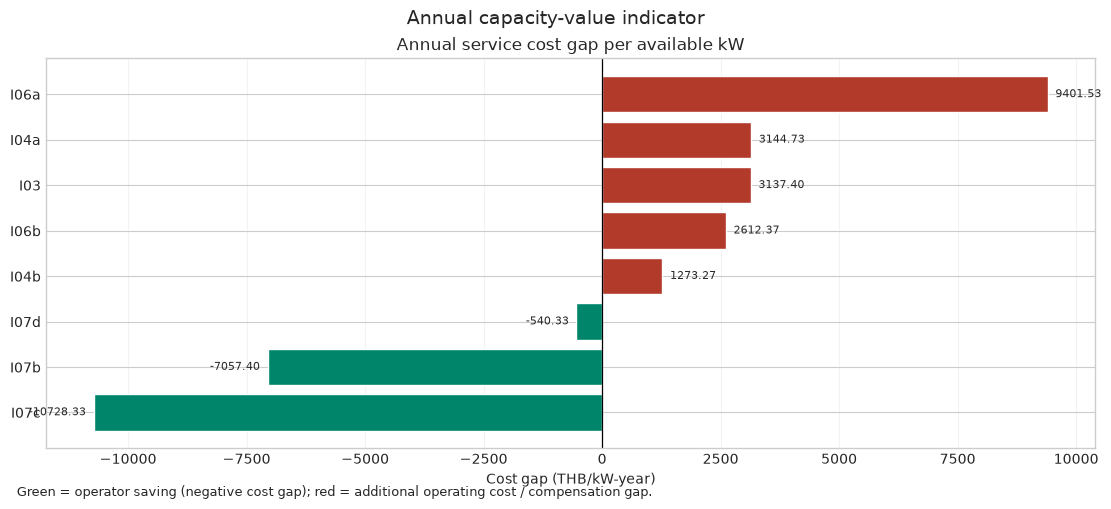

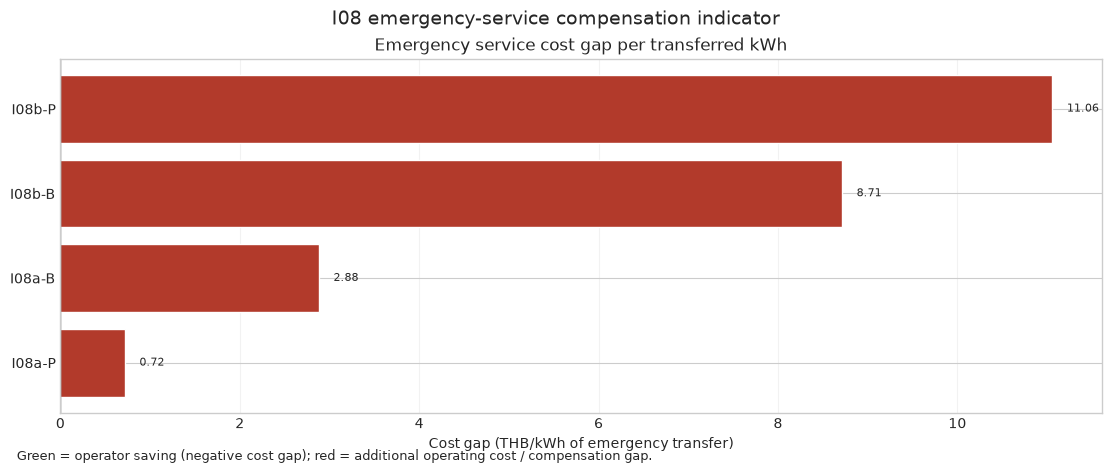

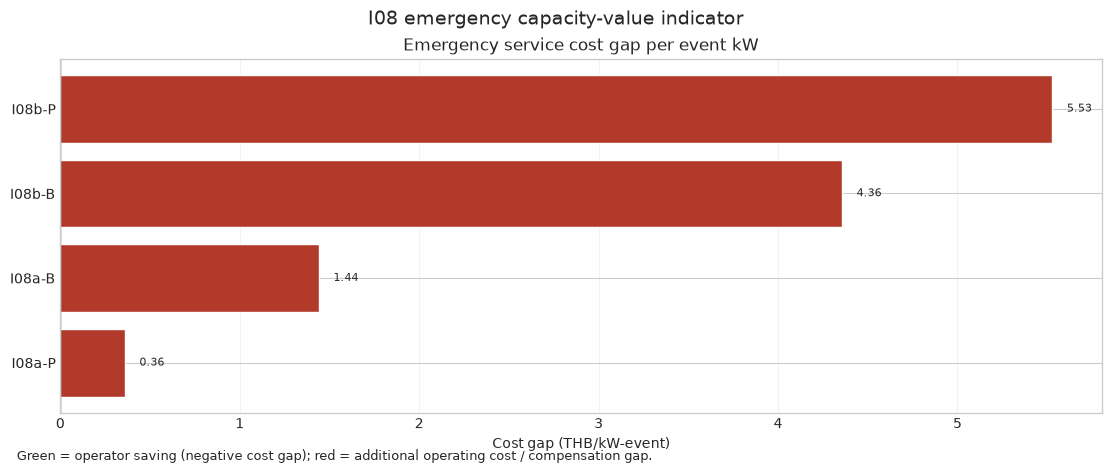

In [30]:
service_cost_gap = build_service_cost_gap(comparison, dispatch_by_case)
if service_cost_gap.empty:
    print('No completed non-revenue service cases are available.')
else:
    cost_gap_columns = [
        'service_type', 'comparison_basis', 'time_basis', 'cost_gap_THB',
        'service_energy_MWh', 'peak_service_kW', 'cost_gap_THB_per_service_kWh',
        'cost_gap_THB_per_kW_year', 'cost_gap_THB_per_kW_event',
        'potential_monthly_demand_charge_exposure_THB', 'unit_cost_status', 'islanding_check',
    ]
    display(service_cost_gap.reindex(columns=cost_gap_columns).round(3))
    emergency_gap = service_cost_gap[service_cost_gap['time_basis'] == 'event']
    if not emergency_gap.empty:
        print('I08 demand-charge values are potential monthly exposure only: whether a charge is actually incurred depends on the unmodelled monthly maximum outside the event window.')
        if not (emergency_gap['islanding_check'] == 'pass').all():
            raise AssertionError('I08 islanding validation failed: non-zero grid flow during an outage.')

# Renewable-responsive cases: report the direct operator effect on the same
# annual bus mobility output, rather than dividing by the small proxy-discharge quantity.
renewable_operator_labels = [
    'V1G baseline',
    'I05 maximum renewable-deficit support without export',
    'I06a maximum renewable-deficit support at 5 kW policy limit',
    'I06b maximum renewable-deficit support at 450 kW technical sensitivity',
]
renewable_operator_rows = []
for label in renewable_operator_labels:
    if label not in comparison.index or label not in dispatch_by_case:
        continue
    trip_energy_mwh = float(dispatch_by_case[label]['bus_trip_energy_MWh'].sum())
    total_cost_thb = float(comparison.loc[label, 'total_cost_THB'])
    renewable_operator_rows.append({
        'scenario': label,
        'annual_bus_traction_energy_MWh': trip_energy_mwh,
        'total_operating_cost_THB': total_cost_thb,
        'operating_cost_THB_per_traction_kWh': total_cost_thb / (trip_energy_mwh * 1000),
    })
renewable_operator_cost = pd.DataFrame(renewable_operator_rows).set_index('scenario') if renewable_operator_rows else pd.DataFrame()
if not renewable_operator_cost.empty and 'V1G baseline' in renewable_operator_cost.index:
    renewable_operator_cost['additional_cost_vs_V1G_THB_per_traction_kWh'] = (
        renewable_operator_cost['operating_cost_THB_per_traction_kWh']
        - renewable_operator_cost.loc['V1G baseline', 'operating_cost_THB_per_traction_kWh']
    )
    print('Renewable-responsive operator cost, using the common annual bus-traction energy denominator:')
    display(renewable_operator_cost.round(3))

# Cost-gap visualisations use only defined service denominators. Negative values are operator savings.
def _plot_cost_gap(frame, value_column, title, xlabel, figure_title):
    plotted = frame[np.isfinite(frame[value_column])].copy()
    if plotted.empty:
        print(f'No defined values available for {title}.')
        return
    plotted = plotted.sort_values(value_column)
    short = {
        'I03 maximum regional high-load import relief without export': 'I03',
        'I04a maximum regional high-load import relief at 5 kW policy limit': 'I04a',
        'I04b maximum regional high-load import relief at 450 kW technical sensitivity': 'I04b',
        'I05 maximum renewable-deficit support without export': 'I05',
        'I06a maximum renewable-deficit support at 5 kW policy limit': 'I06a',
        'I06b maximum renewable-deficit support at 450 kW technical sensitivity': 'I06b',
        'I07b rooftop PV operation at current export policy': 'I07b',
        'I07c rooftop PV operation at viable export tariff': 'I07c',
        'I07d PV with high-load demand management': 'I07d',
        'I08a-P emergency V2G 4 h prepared SOC': 'I08a-P',
        'I08a-B emergency V2G 4 h inherited SOC': 'I08a-B',
        'I08b-P emergency V2G 8 h prepared SOC': 'I08b-P',
        'I08b-B emergency V2G 8 h inherited SOC': 'I08b-B',
    }
    labels = [short.get(name, name) for name in plotted.index]
    values = plotted[value_column].to_numpy(dtype=float)
    colors = ['#00856a' if value < 0 else '#b23a2b' for value in values]
    fig, ax = plt.subplots(figsize=(11, max(4.5, 0.42 * len(plotted) + 1.5)), constrained_layout=True)
    bars = ax.barh(labels, values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.9)
    span = max(float(np.max(np.abs(values))), 1.0)
    for bar, value in zip(bars, values):
        offset = 0.015 * span if value >= 0 else -0.015 * span
        ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f'{value:.2f}', va='center', ha='left' if value >= 0 else 'right', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', alpha=0.25)
    ax.set_axisbelow(True)
    fig.suptitle(figure_title, fontsize=14)
    fig.text(0.01, -0.01, 'Green = operator saving (negative cost gap); red = additional operating cost / compensation gap.', fontsize=9)
    plt.show()

if not service_cost_gap.empty:
    annual_gap = service_cost_gap[service_cost_gap['time_basis'] == 'annual']
    event_gap = service_cost_gap[service_cost_gap['time_basis'] == 'event']
    _plot_cost_gap(annual_gap, 'cost_gap_THB_per_service_kWh', 'Annual service cost gap per delivered kWh', 'Cost gap (THB/kWh of service)', 'Annual non-revenue service compensation indicator')
    _plot_cost_gap(annual_gap, 'cost_gap_THB_per_kW_year', 'Annual service cost gap per available kW', 'Cost gap (THB/kW-year)', 'Annual capacity-value indicator')
    _plot_cost_gap(event_gap, 'cost_gap_THB_per_service_kWh', 'Emergency service cost gap per transferred kWh', 'Cost gap (THB/kWh of emergency transfer)', 'I08 emergency-service compensation indicator')
    _plot_cost_gap(event_gap, 'cost_gap_THB_per_kW_event', 'Emergency service cost gap per event kW', 'Cost gap (THB/kW-event)', 'I08 emergency capacity-value indicator')


### Thailand benefit and beneficiary analysis

The current tariff leaves most non-revenue grid, renewable-alignment, and resilience value with the power system or public sector while the fleet operator bears the operating cost and SOC-readiness burden. The preceding cost-gap table therefore identifies the operational payment evidence required for a future measured energy-service or availability-service product.

The relevant distribution utility is conditional on location: PEA serves provincial areas outside Bangkok, Nonthaburi, and Samut Prakan; MEA serves the metropolitan service area. EGAT is relevant to national system operation and transmission; ERC regulates energy-industry operation and tariff-related rules. These institutional roles do not establish permission for the modelled V2G services. [PEA service territory](https://www.pea.co.th/about-pea/pea-service), [EGAT transmission and system control](https://www.egat.co.th/home/en/transmission-line/), and [ERC statutory role](https://www.erc.or.th/en/history-page).

No avoided network investment, external critical-load value, battery degradation, charger/PV CAPEX, or social value is monetised here. Network benefit requires local validation, telemetry, protection, settlement rules, and an approved operating agreement.


In [31]:
display(stakeholder_matrix())

if not service_cost_gap.empty:
    beneficiary_evidence = service_cost_gap[['service_type', 'time_basis', 'service_energy_MWh', 'peak_service_kW', 'cost_gap_THB', 'cost_gap_THB_per_service_kWh']].copy()
    beneficiary_evidence['who_benefits'] = np.where(
        beneficiary_evidence['service_type'].str.contains('emergency'),
        'Passengers / transport authority / resilience planners',
        np.where(beneficiary_evidence['service_type'].str.contains('PV'), 'Depot/PV owner and utility', 'Distribution utility / system operator'),
    )
    beneficiary_evidence['who_bears_operating_gap_now'] = 'Fleet / depot operator unless a service contract pays it'
    display(beneficiary_evidence.round(3))


,benefit,responsibility / exposure,decision-relevant metric
stakeholder,,,
Fleet / public-bus operator,Mobility-compliant charging; any operating saving,"SOC readiness, recovery energy and peak-demand...",Energy-service THB/kWh; availability THB/kW-ye...
"Depot owner, PV owner and charging-service provider","PV utilisation, controlled export and service ...","Charger controls, metering, protection and set...",PV-V2G service cost-gap metric
PEA or MEA distribution utility,Potential local regional-high-load-period net-...,"Connection approval, local-network validation ...",Verified high-load import-relief THB/kWh and a...
EGAT system operator,Potential system-support signal response,Dispatch coordination; no claimed avoided tran...,Only after a defined system-service product
"ERC, EPPO and Ministry of Energy","Evidence for pilot tariff, settlement and cons...","Interconnection, measurement, allocation of va...","Use cost gaps as procurement evidence, not tar..."
"Passengers, transport authorities and wider society","Mobility continuity, resilience insight and lo...",No external critical-load or social value mone...,Public value remains unpriced in this operatio...


,service_type,time_basis,service_energy_MWh,peak_service_kW,cost_gap_THB,cost_gap_THB_per_service_kWh,who_benefits,who_bears_operating_gap_now
scenario,,,,,,,,
I03 maximum regional high-load import relief without export,regional high-load import relief,annual,3.194,87.368,274109.463,85.822,Distribution utility / system operator,Fleet / depot operator unless a service contra...
I04a maximum regional high-load import relief at 5 kW policy limit,regional high-load import relief,annual,3.578,92.368,290474.085,81.190,Distribution utility / system operator,Fleet / depot operator unless a service contra...
I04b maximum regional high-load import relief at 450 kW technical sensitivity,regional high-load import relief,annual,9.626,387.368,493224.936,51.238,Distribution utility / system operator,Fleet / depot operator unless a service contra...
I05 maximum renewable-deficit support without export,renewable-equivalent proxy service,annual,0.000,87.368,858794.242,NaN,Distribution utility / system operator,Fleet / depot operator unless a service contra...
I06a maximum renewable-deficit support at 5 kW policy limit,renewable-equivalent proxy service,annual,0.310,92.369,868405.891,2798.459,Distribution utility / system operator,Fleet / depot operator unless a service contra...
I06b maximum renewable-deficit support at 450 kW technical sensitivity,renewable-equivalent proxy service,annual,1.409,330.443,863240.541,612.787,Distribution utility / system operator,Fleet / depot operator unless a service contra...
I07b rooftop PV operation at current export policy,rooftop-PV export,annual,16.028,5.000,-35287.023,-2.202,Depot/PV owner and utility,Fleet / depot operator unless a service contra...
I07c rooftop PV operation at viable export tariff,rooftop-PV export,annual,23.844,5.000,-53641.673,-2.250,Depot/PV owner and utility,Fleet / depot operator unless a service contra...
I07d PV with high-load demand management,PV high-load demand management,annual,0.755,65.683,-35490.054,-46.982,Depot/PV owner and utility,Fleet / depot operator unless a service contra...


## Appendix A. Site, route, and roof context


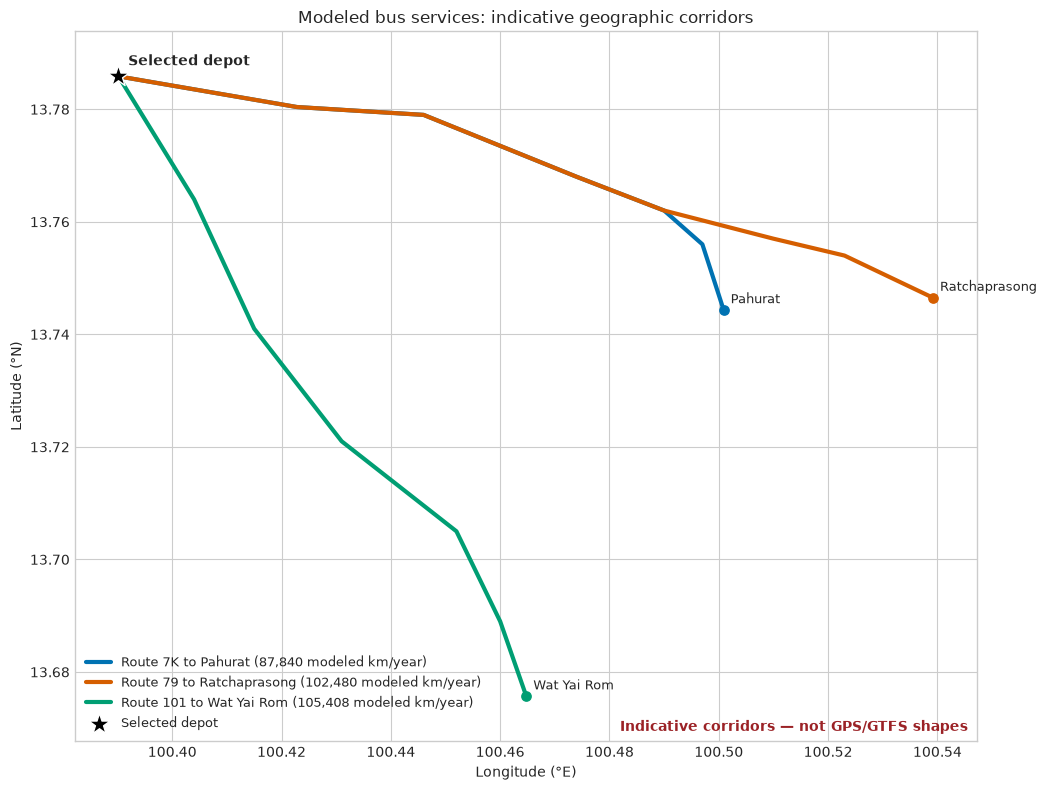

In [32]:
with ROUTE_PATH.open(encoding='utf-8') as stream:
    route_geojson = json.load(stream)
figure, axis = plt.subplots(figsize=(12, 8))
all_lon, all_lat = [], []
for feature in route_geojson['features']:
    coordinates = np.asarray(feature['geometry']['coordinates'])
    properties = feature['properties']
    bus_name = properties['model_bus']
    annual_km = route_totals.get(bus_name, np.nan)
    label = f"Route {properties['route_id']} to {properties['terminus']} ({annual_km:,.0f} modeled km/year)"
    axis.plot(coordinates[:, 0], coordinates[:, 1], linewidth=3, color=properties['color'], label=label)
    axis.scatter(coordinates[-1, 0], coordinates[-1, 1], s=45, color=properties['color'], zorder=4)
    axis.annotate(properties['terminus'], coordinates[-1], xytext=(5, 5), textcoords='offset points', fontsize=9)
    all_lon.extend(coordinates[:, 0])
    all_lat.extend(coordinates[:, 1])
depot_lon, depot_lat = 100.3901683, 13.7858496
axis.scatter(depot_lon, depot_lat, marker='*', s=260, color='black', edgecolor='white', linewidth=1, zorder=5, label='Selected depot')
axis.annotate('Selected depot', (depot_lon, depot_lat), xytext=(7, 8), textcoords='offset points', fontweight='bold')
axis.set_xlim(min(all_lon) - 0.008, max(all_lon) + 0.008)
axis.set_ylim(min(all_lat) - 0.008, max(all_lat) + 0.008)
axis.set_aspect(1 / np.cos(np.deg2rad(np.mean(all_lat))))
axis.set(xlabel='Longitude (°E)', ylabel='Latitude (°N)', title='Modeled bus services: indicative geographic corridors')
axis.legend(loc='lower left', fontsize=9)
axis.text(0.99, 0.01, 'Indicative corridors — not GPS/GTFS shapes', transform=axis.transAxes, ha='right', va='bottom', color='#9B2226', fontweight='bold')
figure.tight_layout()
plt.show()


### Interactive road basemap


In [33]:
road_map = go.Figure()
route_km_total = 0.0
for feature in route_geojson['features']:
    coordinates = np.asarray(feature['geometry']['coordinates'])
    properties = feature['properties']
    route_id = properties['route_id']
    terminus = properties['terminus']
    color = properties['color']
    annual_km = float(route_totals.get(properties['model_bus'], 0.0))
    route_km_total += annual_km

    # A pale casing keeps each corridor visible above the road basemap.
    road_map.add_trace(go.Scattermap(
        lon=coordinates[:, 0], lat=coordinates[:, 1], mode='lines',
        line={'width': 10, 'color': 'rgba(255, 255, 255, 0.90)'},
        hoverinfo='skip', showlegend=False,
    ))
    road_map.add_trace(
        go.Scattermap(
            lon=coordinates[:, 0],
            lat=coordinates[:, 1],
            mode='lines+markers',
            line={'width': 5, 'color': color},
            marker={'size': 5, 'color': color},
            name=f"Route {properties['route_id']} — {properties['terminus']}",
            hovertemplate=(
                f"Route {properties['route_id']}<br>Terminus: {properties['terminus']}"
                f'<br>Modeled distance: {annual_km:,.0f} km/year'
                '<br>Indicative service corridor<extra></extra>'
            ),
        )
    )

    # A route identifier and terminus pin make the service pattern legible.
    badge_index = max(1, int((len(coordinates) - 1) * 0.65))
    road_map.add_trace(go.Scattermap(
        lon=[coordinates[badge_index, 0]], lat=[coordinates[badge_index, 1]],
        mode='markers+text',
        marker={'size': 20, 'color': color},
        text=[route_id], textposition='middle center',
        textfont={'color': 'white', 'size': 10}, showlegend=False,
        hovertemplate=f'<b>Route {route_id}</b><br>Outbound to {terminus}<extra></extra>',
    ))
    road_map.add_trace(go.Scattermap(
        lon=[coordinates[-1, 0]], lat=[coordinates[-1, 1]],
        mode='markers+text',
        marker={'size': 13, 'color': color},
        text=[f'{route_id}: {terminus}'], textposition='top right',
        textfont={'color': color, 'size': 11}, showlegend=False,
        hovertemplate=f'<b>Route {route_id} terminus</b><br>{terminus}<extra></extra>',
    ))
# The depot beacon is deliberately drawn last, above all route origins.
road_map.add_trace(go.Scattermap(
    lon=[depot_lon], lat=[depot_lat], mode='markers',
    marker={'size': 38, 'color': '#F4A261'},
    showlegend=False, hoverinfo='skip',
))
road_map.add_trace(
    go.Scattermap(
        lon=[depot_lon],
        lat=[depot_lat],
        mode='markers+text',
        marker={'size': 18, 'color': '#111111'},
        text=['BUS DEPOT'],
        textposition='top right',
        textfont={'color': '#111111', 'size': 14},
        name='Selected depot',
        hovertemplate='<b>Selected depot</b><br>Origin of all modeled services<extra></extra>',
    )
)
road_map.update_layout(
    title={'text': 'Modeled bus-service network <sup>outbound indicative corridors</sup>', 'x': 0.01, 'xanchor': 'left'},
    map={'style': 'open-street-map', 'center': {'lon': 100.465, 'lat': 13.735}, 'zoom': 10.35},
    margin={'l': 0, 'r': 0, 't': 50, 'b': 0},
    legend={'orientation': 'h', 'y': 0.01, 'x': 0.01, 'xanchor': 'left', 'bgcolor': 'rgba(255, 255, 255, 0.85)'},
    annotations=[
        {
            'text': f'3 modeled services | {route_km_total:,.0f} vehicle-km/year',
            'xref': 'paper',
            'yref': 'paper',
            'x': 0.01,
            'y': 0.96,
            'xanchor': 'left',
            'yanchor': 'top',
            'showarrow': False,
            'bgcolor': 'rgba(255, 255, 255, 0.88)',
            'bordercolor': 'rgba(0, 0, 0, 0.18)',
            'borderwidth': 1,
        },
        {
            'text': 'Route lines are indicative corridors, not GPS/GTFS shapes. Map data © OpenStreetMap contributors.',
            'xref': 'paper',
            'yref': 'paper',
            'x': 0.99,
            'y': 0.01,
            'xanchor': 'right',
            'yanchor': 'bottom',
            'showarrow': False,
            'bgcolor': 'rgba(255, 255, 255, 0.80)',
        }
    ],
)
road_map.show()


### Depot roof geometry and PV potential


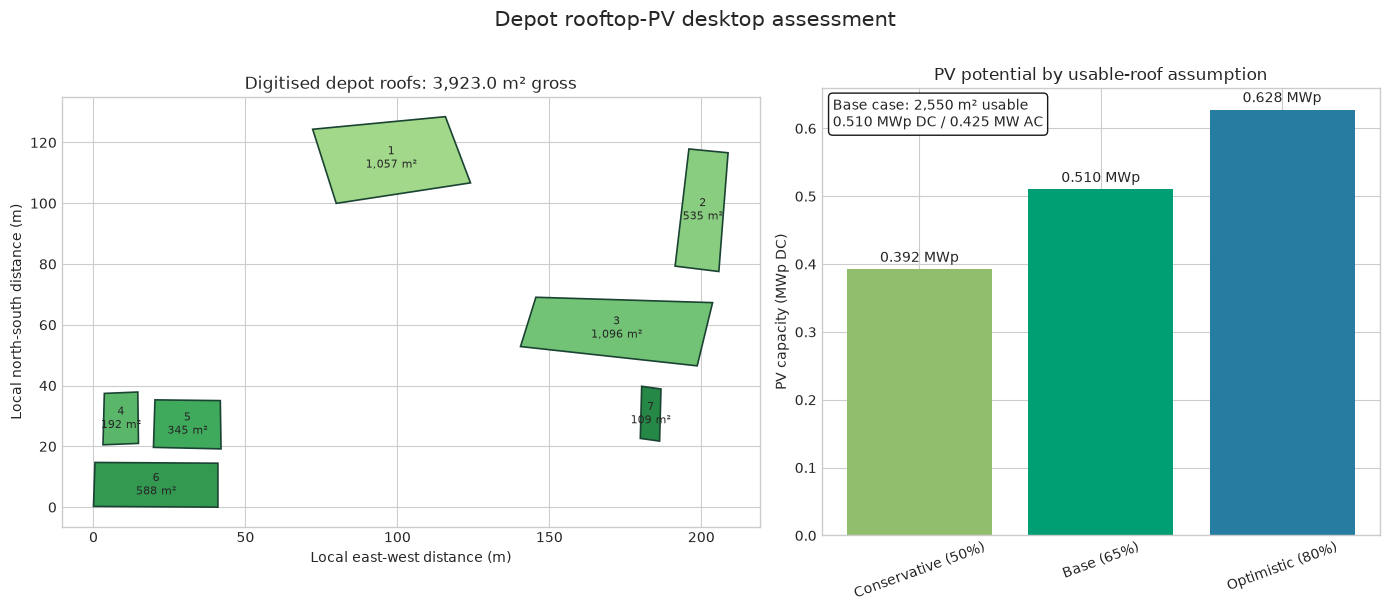

,usable_fraction,usable_area_m2,pv_capacity_mwp_dc,inverter_capacity_mw_ac
Conservative (50%),0.50,1961.50,0.392,0.327
Base (65%),0.65,2549.95,0.510,0.425
Optimistic (80%),0.80,3138.40,0.628,0.523


In [34]:
with ROOF_PATH.open(encoding='utf-8') as stream:
    roof_geojson = json.load(stream)
features = roof_geojson['features']
all_coordinates = np.vstack([np.asarray(feature['geometry']['coordinates'][0]) for feature in features])
origin_lon, origin_lat = all_coordinates[:, 0].min(), all_coordinates[:, 1].min()
metres_per_degree_lat = 111_320
metres_per_degree_lon = metres_per_degree_lat * np.cos(np.deg2rad(origin_lat))
gross_area_m2 = sum(float(feature['properties']['gross_area_m2']) for feature in features)
usable_fractions = pd.Series({'Conservative (50%)': 0.50, 'Base (65%)': 0.65, 'Optimistic (80%)': 0.80})
pv_capacity_mwp = gross_area_m2 * usable_fractions * 0.20 / 1000
figure, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.25, 1]})
for index, feature in enumerate(features, start=1):
    lon_lat = np.asarray(feature['geometry']['coordinates'][0])
    x = (lon_lat[:, 0] - origin_lon) * metres_per_degree_lon
    y = (lon_lat[:, 1] - origin_lat) * metres_per_degree_lat
    area = float(feature['properties']['gross_area_m2'])
    axes[0].fill(x, y, color=plt.cm.YlGn(0.35 + 0.055 * index), edgecolor='#1B4332', linewidth=1.2)
    axes[0].text(x[:-1].mean(), y[:-1].mean(), f'{index}\n{area:,.0f} m²', ha='center', va='center', fontsize=8)
axes[0].set_aspect('equal')
axes[0].set(xlabel='Local east-west distance (m)', ylabel='Local north-south distance (m)', title=f'Digitised depot roofs: {gross_area_m2:,.1f} m² gross')
bars = axes[1].bar(pv_capacity_mwp.index, pv_capacity_mwp.values, color=['#90BE6D', COLORS['green'], '#277DA1'])
axes[1].bar_label(bars, labels=[f'{value:.3f} MWp' for value in pv_capacity_mwp], padding=3)
axes[1].set(ylabel='PV capacity (MWp DC)', title='PV potential by usable-roof assumption')
axes[1].tick_params(axis='x', rotation=20)
base_dc_mwp = float(pv_capacity_mwp['Base (65%)'])
base_usable_area_m2 = gross_area_m2 * float(usable_fractions['Base (65%)'])
axes[1].text(0.02, 0.98, f'Base case: {base_usable_area_m2:,.0f} m² usable\n{base_dc_mwp:.3f} MWp DC / {base_dc_mwp / 1.20:.3f} MW AC', transform=axes[1].transAxes, va='top', bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.9})
figure.suptitle('Depot rooftop-PV desktop assessment', fontsize=15, y=1.01)
figure.tight_layout()
plt.show()
roof_table = pd.DataFrame({'usable_fraction': usable_fractions, 'usable_area_m2': gross_area_m2 * usable_fractions, 'pv_capacity_mwp_dc': pv_capacity_mwp, 'inverter_capacity_mw_ac': pv_capacity_mwp / 1.20})
display(roof_table.round(3))


### Interactive satellite roof map


In [35]:
roof_center = all_coordinates.mean(axis=0)
base_usable_fraction = 0.65
module_density_kwp_per_m2 = 0.20

satellite_roof_map = go.Figure()
for index, feature in enumerate(features, start=1):
    coordinates = np.asarray(feature['geometry']['coordinates'][0])
    properties = feature['properties']
    gross_roof_area_m2 = float(properties['gross_area_m2'])
    base_pv_kwp = gross_roof_area_m2 * base_usable_fraction * module_density_kwp_per_m2
    satellite_roof_map.add_trace(
        go.Scattermap(
            lon=coordinates[:, 0], lat=coordinates[:, 1], mode='lines', fill='toself',
            fillcolor='rgba(46, 204, 113, 0.34)',
            line={'color': '#0B5345', 'width': 2},
            name=f'Roof {index}',
            hovertemplate=(
                f'<b>Roof {index}</b><br>Gross area: {gross_roof_area_m2:,.1f} m²'
                f'<br>Base-case PV potential: {base_pv_kwp:,.1f} kWp DC'
                '<br>Usable-roof assumption: 65%<extra></extra>'
            ),
        )
    )

satellite_roof_map.add_trace(
    go.Scattermap(
        lon=[roof_center[0]], lat=[roof_center[1]], mode='markers', name='Depot',
        marker={'size': 11, 'color': '#C0392B'},
        hovertemplate='<b>Depot roof cluster</b><extra></extra>',
    )
)
satellite_roof_map.update_layout(
    title='Depot roofs and indicative PV potential',
    map={
        'style': 'white-bg',
        'center': {'lon': roof_center[0], 'lat': roof_center[1]},
        'zoom': 17.2,
        'layers': [{
            'sourcetype': 'raster',
            'source': ['https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'],
            'below': 'traces',
        }],
    },
    margin={'l': 0, 'r': 0, 't': 45, 'b': 0},
    legend={'orientation': 'h', 'y': 0.01, 'x': 0.01},
    annotations=[{
        'text': ('Imagery sources: Esri, DigitalGlobe, GeoEye, i-cubed, USDA FSA, USGS, AEX, '
                 'Getmapping, Aerogrid, IGN, IGP, swisstopo, and the GIS User Community. '
                 'Visual reference only; imagery date not confirmed.'),
        'xref': 'paper', 'yref': 'paper', 'x': 0.01, 'y': 0.02,
        'xanchor': 'left', 'yanchor': 'bottom', 'showarrow': False,
        'font': {'size': 9, 'color': '#1F2937'},
        'bgcolor': 'rgba(255, 255, 255, 0.82)',
    }],
)
satellite_roof_map.show()


## Appendix B. Supplementary tariff and export-limit sensitivities


/tmp/ipykernel_2021259/1583869699.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
/tmp/ipykernel_2021259/1583869699.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
/tmp/ipykernel_2021259/1583869699.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

Missing Export +2.0 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_2000
Missing Export +2.5 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_2500
Missing Export +3.0 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_3000
Missing Export +3.5 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_3500
Missing Export +4.0 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_4000
Missing Export +4.5 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_4500
Missing Export +5.0 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_5000


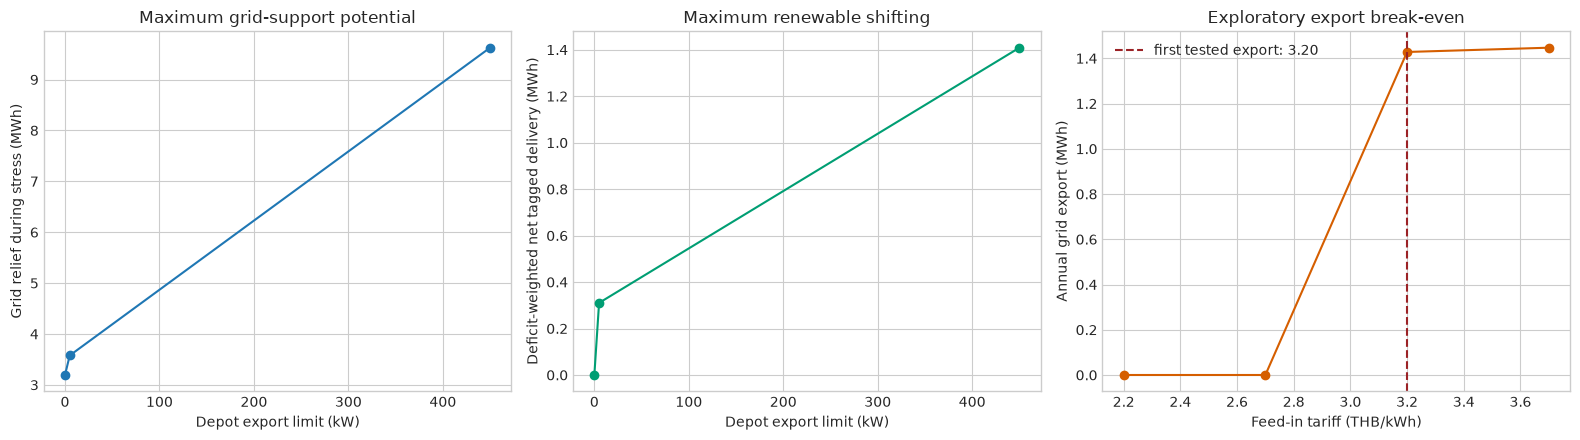

In [36]:
def sensitivity_frame(cases: dict, parameter: str) -> pd.DataFrame:
    rows = []
    for label, spec in cases.items():
        run_case(label, spec, RUN_SENSITIVITY_CASES)
        loaded = load_result(label, spec)
        if loaded is None:
            continue
        row, dispatch = loaded
        if 'V1G baseline' in dispatch_by_case:
            baseline = dispatch_by_case['V1G baseline']
            common_index = baseline.index.intersection(dispatch.index)
            relief = baseline.loc[common_index, 'net_grid_import_MWh'] - dispatch.loc[common_index, 'net_grid_import_MWh']
            threshold = float(dispatch.loc[common_index, 'grid_stress_threshold'].iloc[0])
            stressed = dispatch.loc[common_index, 'grid_congestion_weight'] >= threshold
            row['grid_support_during_stress_MWh'] = float(relief.loc[stressed].sum())
        row[parameter] = spec[parameter]
        rows.append(row)
    return pd.DataFrame(rows).sort_values(parameter) if rows else pd.DataFrame()

grid_sensitivity = sensitivity_frame(GRID_SUPPORT_CASES, 'export_limit_kw')
renewable_sensitivity = sensitivity_frame(RENEWABLE_CASES, 'export_limit_kw')
tariff_sensitivity = sensitivity_frame(TARIFF_CASES, 'increment_thb_per_kwh')
figure, axes = plt.subplots(1, 3, figsize=(16, 4.5))
if not grid_sensitivity.empty:
    axes[0].plot(grid_sensitivity['export_limit_kw'], grid_sensitivity['grid_support_during_stress_MWh'], marker='o')
    axes[0].set(xlabel='Depot export limit (kW)', ylabel='Grid relief during stress (MWh)', title='Maximum grid-support potential')
else:
    axes[0].text(0.5, 0.5, 'Sensitivity outputs not run', ha='center')
if not renewable_sensitivity.empty:
    axes[1].plot(renewable_sensitivity['export_limit_kw'], renewable_sensitivity['renewable_deficit_support_MWh'], marker='o', color=COLORS['green'])
    axes[1].set(xlabel='Depot export limit (kW)', ylabel='Deficit-weighted net tagged delivery (MWh)', title='Maximum renewable shifting')
else:
    axes[1].text(0.5, 0.5, 'Sensitivity outputs not run', ha='center')
if not tariff_sensitivity.empty:
    axes[2].plot(tariff_sensitivity['increment_thb_per_kwh'] + 2.20, tariff_sensitivity['grid_export_MWh'], marker='o', color=COLORS['orange'])
    axes[2].set(xlabel='Feed-in tariff (THB/kWh)', ylabel='Annual grid export (MWh)', title='Exploratory export break-even')
    exported = tariff_sensitivity.loc[tariff_sensitivity['grid_export_MWh'] > 1e-6]
    if not exported.empty:
        break_even = 2.20 + float(exported.iloc[0]['increment_thb_per_kwh'])
        axes[2].axvline(break_even, color='#9B2226', linestyle='--', label=f'first tested export: {break_even:.2f}')
        axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'Tariff sweep outputs not run', ha='center')
figure.tight_layout()
plt.show()
